In [6]:
# ============================================================
# CELL 1 — Create clean weekly demand dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load integrated daily dataset
df = pd.read_csv("../data/processed/analysis_ready.csv")

# Convert date
df["date"] = pd.to_datetime(df["date"])

# Create Monday-based week
df["week_start"] = (
    df["date"]
    .dt.to_period("W-SUN")
    .apply(lambda x: x.start_time)
)

# Aggregate daily sales to weekly SKU demand
weekly = (
    df.groupby(["sku_id", "week_start"])
      .agg(
          days_observed=("date", "nunique"),
          weekly_demand=("units_sold", "sum")
      )
      .reset_index()
)

# Keep only complete 7-day SKU-weeks
weekly = weekly[
    weekly["days_observed"] == 7
].copy()

# Sort chronologically
weekly = weekly.sort_values(
    ["sku_id", "week_start"]
).reset_index(drop=True)

print("Weekly dataset created")
print("=" * 50)
print("Rows:", len(weekly))
print("SKUs:", weekly["sku_id"].nunique())
print("Weeks:", weekly["week_start"].nunique())
print(
    "Date range:",
    weekly["week_start"].min(),
    "to",
    weekly["week_start"].max()
)

display(weekly.head(10))

Weekly dataset created
Rows: 2949
SKUs: 40
Weeks: 77
Date range: 2025-01-06 00:00:00 to 2026-06-22 00:00:00


,sku_id,week_start,days_observed,weekly_demand
0,SKU001,2025-01-06,7,431.0
1,SKU001,2025-01-13,7,397.0
2,SKU001,2025-01-20,7,420.0
3,SKU001,2025-01-27,7,403.0
4,SKU001,2025-02-03,7,424.0
5,SKU001,2025-02-10,7,343.0
6,SKU001,2025-02-17,7,342.0
7,SKU001,2025-02-24,7,380.0
8,SKU001,2025-03-03,7,359.0
9,SKU001,2025-03-10,7,356.0


In [10]:
# ============================================================
# CELL 2 — Weekly calendar and promotion features
# ============================================================

calendar = pd.read_csv(
    "../data/processed/calendar_clean.csv"
)

calendar["date"] = pd.to_datetime(calendar["date"])

# Create the same Monday-based week
calendar["week_start"] = (
    calendar["date"]
    .dt.to_period("W-SUN")
    .apply(lambda x: x.start_time)
)

# Aggregate calendar information to weekly level
weekly_calendar = (
    calendar.groupby("week_start")
    .agg(
        promo_days=("promo_flag", "sum"),
        holiday_days=("is_holiday", "sum"),
        promo_week=("promo_flag", "max"),
        holiday_week=("is_holiday", "max")
    )
    .reset_index()
)

# Get the main promotion event for each week
weekly_promo_event = (
    calendar[calendar["promo_flag"] == 1]
    .groupby("week_start")["promo_event"]
    .agg(
        lambda x: x.dropna().iloc[0]
        if x.dropna().shape[0] > 0
        else "No Promotion"
    )
    .reset_index()
    .rename(columns={"promo_event": "promo_event"})
)

# Merge promotion event
weekly_calendar = weekly_calendar.merge(
    weekly_promo_event,
    on="week_start",
    how="left"
)

weekly_calendar["promo_event"] = (
    weekly_calendar["promo_event"]
    .fillna("No Promotion")
)

print("Weekly calendar shape:", weekly_calendar.shape)

display(weekly_calendar.head(15))

Weekly calendar shape: (79, 6)


,week_start,promo_days,holiday_days,promo_week,holiday_week,promo_event
0,2024-12-30,0,0,0,0,No Promotion
1,2025-01-06,3,0,1,0,New Year Sale
2,2025-01-13,3,0,1,0,New Year Sale
3,2025-01-20,0,1,0,1,No Promotion
4,2025-01-27,0,0,0,0,No Promotion
5,2025-02-03,0,0,0,0,No Promotion
6,2025-02-10,0,0,0,0,No Promotion
7,2025-02-17,0,0,0,0,No Promotion
8,2025-02-24,0,0,0,0,No Promotion
9,2025-03-03,0,0,0,0,No Promotion


In [13]:
# ============================================================
# CELL 3 — Merge weekly calendar features
# ============================================================

weekly = weekly.merge(
    weekly_calendar,
    on="week_start",
    how="left"
)

# Validate merge
calendar_columns = [
    "promo_days",
    "holiday_days",
    "promo_week",
    "holiday_week",
    "promo_event"
]

print("Missing calendar values:")

display(
    weekly[calendar_columns]
    .isna()
    .sum()
)

print("\nWeekly dataset shape after calendar merge:")
print(weekly.shape)

display(
    weekly[
        [
            "sku_id",
            "week_start",
            "weekly_demand",
            "promo_days",
            "promo_week",
            "holiday_days",
            "promo_event"
        ]
    ].head(15)
)

Missing calendar values:


promo_days      0
holiday_days    0
promo_week      0
holiday_week    0
promo_event     0
dtype: int64


Weekly dataset shape after calendar merge:
(2949, 9)


,sku_id,week_start,weekly_demand,promo_days,promo_week,holiday_days,promo_event
0,SKU001,2025-01-06,431.0,3,1,0,New Year Sale
1,SKU001,2025-01-13,397.0,3,1,0,New Year Sale
2,SKU001,2025-01-20,420.0,0,0,1,No Promotion
3,SKU001,2025-01-27,403.0,0,0,0,No Promotion
4,SKU001,2025-02-03,424.0,0,0,0,No Promotion
5,SKU001,2025-02-10,343.0,0,0,0,No Promotion
6,SKU001,2025-02-17,342.0,0,0,0,No Promotion
7,SKU001,2025-02-24,380.0,0,0,0,No Promotion
8,SKU001,2025-03-03,359.0,0,0,0,No Promotion
9,SKU001,2025-03-10,356.0,0,0,0,No Promotion


In [15]:
# ============================================================
# CELL 4 — Weekly calendar/time features
# ============================================================

weekly["month"] = weekly["week_start"].dt.month

weekly["quarter"] = (
    weekly["week_start"].dt.quarter
)

weekly["year"] = (
    weekly["week_start"].dt.year
)

weekly["week_of_year"] = (
    weekly["week_start"]
    .dt.isocalendar()
    .week
    .astype(int)
)

# Cyclical encoding of week-of-year
weekly["week_sin"] = np.sin(
    2 * np.pi * weekly["week_of_year"] / 52
)

weekly["week_cos"] = np.cos(
    2 * np.pi * weekly["week_of_year"] / 52
)

# Cyclical encoding of month
weekly["month_sin"] = np.sin(
    2 * np.pi * weekly["month"] / 12
)

weekly["month_cos"] = np.cos(
    2 * np.pi * weekly["month"] / 12
)

print("Weekly calendar features created.")

display(
    weekly[
        [
            "week_start",
            "month",
            "quarter",
            "week_of_year",
            "week_sin",
            "week_cos",
            "month_sin",
            "month_cos"
        ]
    ].head(10)
)

Weekly calendar features created.


,week_start,month,quarter,week_of_year,week_sin,week_cos,month_sin,month_cos
0,2025-01-06,1,1,2,0.239316,0.970942,0.500000,8.660254e-01
1,2025-01-13,1,1,3,0.354605,0.935016,0.500000,8.660254e-01
2,2025-01-20,1,1,4,0.464723,0.885456,0.500000,8.660254e-01
3,2025-01-27,1,1,5,0.568065,0.822984,0.500000,8.660254e-01
4,2025-02-03,2,1,6,0.663123,0.748511,0.866025,5.000000e-01
5,2025-02-10,2,1,7,0.748511,0.663123,0.866025,5.000000e-01
6,2025-02-17,2,1,8,0.822984,0.568065,0.866025,5.000000e-01
7,2025-02-24,2,1,9,0.885456,0.464723,0.866025,5.000000e-01
8,2025-03-03,3,1,10,0.935016,0.354605,1.000000,6.123234e-17
9,2025-03-10,3,1,11,0.970942,0.239316,1.000000,6.123234e-17


In [16]:
# ============================================================
# CELL 5 — Add SKU metadata
# ============================================================

sku_master = pd.read_csv(
    "../data/processed/sku_master_clean.csv"
)

# Keep only useful static SKU attributes
sku_features = sku_master[
    [
        "sku_id",
        "category",
        "subcategory",
        "unit_cost",
        "list_price"
    ]
].copy()

weekly = weekly.merge(
    sku_features,
    on="sku_id",
    how="left"
)

print("SKU metadata merged.")

print("\nMissing SKU metadata:")
display(
    weekly[
        [
            "category",
            "subcategory",
            "unit_cost",
            "list_price"
        ]
    ].isna().sum()
)

display(
    weekly[
        [
            "sku_id",
            "category",
            "subcategory",
            "unit_cost",
            "list_price"
        ]
    ].drop_duplicates("sku_id").head(10)
)

SKU metadata merged.

Missing SKU metadata:


category        0
subcategory     0
unit_cost      77
list_price      0
dtype: int64

,sku_id,category,subcategory,unit_cost,list_price
0,SKU001,Furniture,Chair,2362.73,4730.28
77,SKU002,Home Decor,Clock,3577.63,4664.22
151,SKU003,Small Appliances,Toaster,3877.36,7387.17
228,SKU004,Office,Organizer,902.13,1404.39
288,SKU005,Furniture,Chair,4655.80,8102.01
365,SKU006,Home Decor,home decor,4166.98,6462.39
442,SKU007,Small Appliances,Toaster,2906.55,3737.54
519,SKU008,Office,Organizer,4189.87,7237.42
596,SKU009,Furniture,Chair,1966.27,4272.13
673,SKU010,Home Decor,Clock,4497.67,8525.33


In [17]:
# ============================================================
# CELL 6 — Historical weekly demand lags
# ============================================================

weekly = weekly.sort_values(
    ["sku_id", "week_start"]
).reset_index(drop=True)

lag_periods = [
    1,
    2,
    4,
    8,
    13,
    26,
    52
]

for lag in lag_periods:

    weekly[f"lag_{lag}_week"] = (
        weekly
        .groupby("sku_id")["weekly_demand"]
        .shift(lag)
    )

print("Weekly demand lag features created.")

lag_columns = [
    f"lag_{lag}_week"
    for lag in lag_periods
]

display(
    weekly[
        [
            "sku_id",
            "week_start",
            "weekly_demand"
        ] + lag_columns
    ].head(60)
)

Weekly demand lag features created.


,sku_id,week_start,weekly_demand,lag_1_week,lag_2_week,lag_4_week,lag_8_week,lag_13_week,lag_26_week,lag_52_week
0,SKU001,2025-01-06,431.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SKU001,2025-01-13,397.0,431.0,NaN,NaN,NaN,NaN,NaN,NaN
2,SKU001,2025-01-20,420.0,397.0,431.0,NaN,NaN,NaN,NaN,NaN
3,SKU001,2025-01-27,403.0,420.0,397.0,NaN,NaN,NaN,NaN,NaN
4,SKU001,2025-02-03,424.0,403.0,420.0,431.0,NaN,NaN,NaN,NaN
5,SKU001,2025-02-10,343.0,424.0,403.0,397.0,NaN,NaN,NaN,NaN
6,SKU001,2025-02-17,342.0,343.0,424.0,420.0,NaN,NaN,NaN,NaN
7,SKU001,2025-02-24,380.0,342.0,343.0,403.0,NaN,NaN,NaN,NaN
8,SKU001,2025-03-03,359.0,380.0,342.0,424.0,431.0,NaN,NaN,NaN
9,SKU001,2025-03-10,356.0,359.0,380.0,343.0,397.0,NaN,NaN,NaN


In [18]:
# ============================================================
# CELL 7 — Leakage-safe rolling demand features
# ============================================================

grouped_demand = (
    weekly
    .groupby("sku_id")["weekly_demand"]
)

# Rolling mean
for window in [4, 8, 13]:

    weekly[f"rolling_mean_{window}_week"] = (
        grouped_demand
        .transform(
            lambda x:
            x.shift(1)
             .rolling(window=window)
             .mean()
        )
    )

# Rolling standard deviation
for window in [4, 8]:

    weekly[f"rolling_std_{window}_week"] = (
        grouped_demand
        .transform(
            lambda x:
            x.shift(1)
             .rolling(window=window)
             .std()
        )
    )

print("Leakage-safe rolling features created.")

rolling_columns = [
    "rolling_mean_4_week",
    "rolling_mean_8_week",
    "rolling_mean_13_week",
    "rolling_std_4_week",
    "rolling_std_8_week"
]

display(
    weekly[
        [
            "sku_id",
            "week_start",
            "weekly_demand"
        ] + rolling_columns
    ].tail(20)
)

Leakage-safe rolling features created.


,sku_id,week_start,weekly_demand,rolling_mean_4_week,rolling_mean_8_week,rolling_mean_13_week,rolling_std_4_week,rolling_std_8_week
2929,SKU040,2026-02-09,528.0,505.00,550.250,532.615385,28.154337,68.610183
2930,SKU040,2026-02-16,490.0,518.25,537.750,542.230769,20.854656,61.122243
2931,SKU040,2026-02-23,546.0,519.00,514.625,538.076923,19.356308,27.557408
2932,SKU040,2026-03-02,471.0,523.50,513.375,535.615385,23.741665,25.567488
2933,SKU040,2026-03-09,439.0,508.75,506.875,535.384615,34.325646,29.132395
2934,SKU040,2026-03-16,605.0,486.50,502.375,528.923077,44.903600,36.586248
2935,SKU040,2026-03-23,507.0,515.25,517.125,527.153846,74.772433,50.603324
2936,SKU040,2026-03-30,454.0,505.50,514.500,514.230769,71.914301,50.503182
2937,SKU040,2026-04-06,475.0,501.25,505.000,506.384615,75.066082,54.184869
2938,SKU040,2026-04-13,416.0,510.25,498.375,502.692308,66.820032,54.211062


In [19]:
# ============================================================
# CELL 8 — Demand trend features
# ============================================================

weekly["demand_trend_4_13"] = (
    weekly["rolling_mean_4_week"]
    - weekly["rolling_mean_13_week"]
)

weekly["demand_trend_8_13"] = (
    weekly["rolling_mean_8_week"]
    - weekly["rolling_mean_13_week"]
)

# Relative trend
weekly["demand_growth_4_13"] = (
    weekly["rolling_mean_4_week"]
    / weekly["rolling_mean_13_week"].replace(0, np.nan)
    - 1
)

print("Demand trend features created.")

display(
    weekly[
        [
            "sku_id",
            "week_start",
            "rolling_mean_4_week",
            "rolling_mean_13_week",
            "demand_trend_4_13",
            "demand_growth_4_13"
        ]
    ].tail(15)
)

Demand trend features created.


,sku_id,week_start,rolling_mean_4_week,rolling_mean_13_week,demand_trend_4_13,demand_growth_4_13
2934,SKU040,2026-03-16,486.50,528.923077,-42.423077,-0.080207
2935,SKU040,2026-03-23,515.25,527.153846,-11.903846,-0.022581
2936,SKU040,2026-03-30,505.50,514.230769,-8.730769,-0.016978
2937,SKU040,2026-04-06,501.25,506.384615,-5.134615,-0.010140
2938,SKU040,2026-04-13,510.25,502.692308,7.557692,0.015034
2939,SKU040,2026-04-20,463.00,498.153846,-35.153846,-0.070568
2940,SKU040,2026-04-27,447.75,495.000000,-47.250000,-0.095455
2941,SKU040,2026-05-04,457.00,492.153846,-35.153846,-0.071429
2942,SKU040,2026-05-11,464.00,490.076923,-26.076923,-0.053210
2943,SKU040,2026-05-18,483.50,487.461538,-3.961538,-0.008127


In [20]:
# ============================================================
# CELL 9 — Promotion interaction features
# ============================================================

weekly["promo_demand_interaction"] = (
    weekly["promo_week"]
    * weekly["rolling_mean_4_week"]
)

weekly["promo_intensity"] = (
    weekly["promo_days"] / 7
)

weekly["holiday_promo_interaction"] = (
    weekly["holiday_week"]
    * weekly["promo_week"]
)

print("Promotion interaction features created.")

display(
    weekly[
        [
            "sku_id",
            "week_start",
            "weekly_demand",
            "promo_days",
            "promo_week",
            "promo_intensity",
            "promo_demand_interaction"
        ]
    ].head(20)
)

Promotion interaction features created.


,sku_id,week_start,weekly_demand,promo_days,promo_week,promo_intensity,promo_demand_interaction
0,SKU001,2025-01-06,431.0,3,1,0.428571,NaN
1,SKU001,2025-01-13,397.0,3,1,0.428571,NaN
2,SKU001,2025-01-20,420.0,0,0,0.000000,NaN
3,SKU001,2025-01-27,403.0,0,0,0.000000,NaN
4,SKU001,2025-02-03,424.0,0,0,0.000000,0.00
5,SKU001,2025-02-10,343.0,0,0,0.000000,0.00
6,SKU001,2025-02-17,342.0,0,0,0.000000,0.00
7,SKU001,2025-02-24,380.0,0,0,0.000000,0.00
8,SKU001,2025-03-03,359.0,0,0,0.000000,0.00
9,SKU001,2025-03-10,356.0,0,0,0.000000,0.00


In [21]:
# ============================================================
# CELL 10 — Feature engineering audit
# ============================================================

print("FEATURE ENGINEERING AUDIT")
print("=" * 60)

print("Rows:", weekly.shape[0])
print("Columns:", weekly.shape[1])
print("SKUs:", weekly["sku_id"].nunique())

print(
    "Date range:",
    weekly["week_start"].min(),
    "to",
    weekly["week_start"].max()
)

print("\nTotal missing values:")
missing = (
    weekly.isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing[missing > 0]
)

print("\nFeature columns:")

for column in weekly.columns:
    print(column)

FEATURE ENGINEERING AUDIT
Rows: 2949
Columns: 39
SKUs: 40
Date range: 2025-01-06 00:00:00 to 2026-06-22 00:00:00

Total missing values:


lag_52_week                 2080
lag_26_week                 1040
demand_trend_4_13            520
demand_trend_8_13            520
lag_13_week                  520
rolling_mean_13_week         520
demand_growth_4_13           520
rolling_std_8_week           320
lag_8_week                   320
rolling_mean_8_week          320
lag_4_week                   160
promo_demand_interaction     160
rolling_std_4_week           160
rolling_mean_4_week          160
lag_2_week                    80
unit_cost                     77
lag_1_week                    40
dtype: int64


Feature columns:
sku_id
week_start
days_observed
weekly_demand
promo_days
holiday_days
promo_week
holiday_week
promo_event
month
quarter
year
week_of_year
week_sin
week_cos
month_sin
month_cos
category
subcategory
unit_cost
list_price
lag_1_week
lag_2_week
lag_4_week
lag_8_week
lag_13_week
lag_26_week
lag_52_week
rolling_mean_4_week
rolling_mean_8_week
rolling_mean_13_week
rolling_std_4_week
rolling_std_8_week
demand_trend_4_13
demand_trend_8_13
demand_growth_4_13
promo_demand_interaction
promo_intensity
holiday_promo_interaction


In [22]:
# ============================================================
# CELL 11 — Missing feature coverage by SKU
# ============================================================

important_history_features = [
    "lag_1_week",
    "lag_2_week",
    "lag_4_week",
    "lag_8_week",
    "lag_13_week",
    "lag_26_week",
    "lag_52_week",
    "rolling_mean_4_week",
    "rolling_mean_8_week",
    "rolling_mean_13_week",
    "rolling_std_4_week",
    "rolling_std_8_week"
]

coverage = (
    weekly
    .groupby("sku_id")[important_history_features]
    .apply(lambda x: x.notna().mean())
)

print("Historical feature coverage by SKU:")
display(coverage.round(3))

Historical feature coverage by SKU:


,lag_1_week,lag_2_week,lag_4_week,lag_8_week,lag_13_week,lag_26_week,lag_52_week,rolling_mean_4_week,rolling_mean_8_week,rolling_mean_13_week,rolling_std_4_week,rolling_std_8_week
sku_id,,,,,,,,,,,,
SKU001,0.987,0.974,0.948,0.896,0.831,0.662,0.325,0.948,0.896,0.831,0.948,0.896
SKU002,0.986,0.973,0.946,0.892,0.824,0.649,0.297,0.946,0.892,0.824,0.946,0.892
SKU003,0.987,0.974,0.948,0.896,0.831,0.662,0.325,0.948,0.896,0.831,0.948,0.896
SKU004,0.983,0.967,0.933,0.867,0.783,0.567,0.133,0.933,0.867,0.783,0.933,0.867
SKU005,0.987,0.974,0.948,0.896,0.831,0.662,0.325,0.948,0.896,0.831,0.948,0.896
SKU006,0.987,0.974,0.948,0.896,0.831,0.662,0.325,0.948,0.896,0.831,0.948,0.896
SKU007,0.987,0.974,0.948,0.896,0.831,0.662,0.325,0.948,0.896,0.831,0.948,0.896
SKU008,0.987,0.974,0.948,0.896,0.831,0.662,0.325,0.948,0.896,0.831,0.948,0.896
SKU009,0.987,0.974,0.948,0.896,0.831,0.662,0.325,0.948,0.896,0.831,0.948,0.896


In [23]:
# ============================================================
# CELL 12 — Save weekly ML feature dataset
# ============================================================

output_path = "../data/processed/weekly_forecasting_features.csv"

weekly.to_csv(
    output_path,
    index=False
)

print("Weekly forecasting feature dataset saved.")
print("File:", output_path)
print("Shape:", weekly.shape)

Weekly forecasting feature dataset saved.
File: ../data/processed/weekly_forecasting_features.csv
Shape: (2949, 39)


In [24]:
# ============================================================
# CELL 13 — Feature coverage summary
# ============================================================

history_features = [
    "lag_1_week",
    "lag_2_week",
    "lag_4_week",
    "lag_8_week",
    "lag_13_week",
    "lag_26_week",
    "lag_52_week",
    "rolling_mean_4_week",
    "rolling_mean_8_week",
    "rolling_mean_13_week",
    "rolling_std_4_week",
    "rolling_std_8_week"
]

coverage_summary = []

for feature in history_features:

    coverage_summary.append({
        "feature": feature,
        "available_rows": weekly[feature].notna().sum(),
        "missing_rows": weekly[feature].isna().sum(),
        "coverage_pct": weekly[feature].notna().mean() * 100
    })

coverage_summary = pd.DataFrame(
    coverage_summary
)

display(
    coverage_summary.round(2)
)

,feature,available_rows,missing_rows,coverage_pct
0,lag_1_week,2909,40,98.64
1,lag_2_week,2869,80,97.29
2,lag_4_week,2789,160,94.57
3,lag_8_week,2629,320,89.15
4,lag_13_week,2429,520,82.37
5,lag_26_week,1909,1040,64.73
6,lag_52_week,869,2080,29.47
7,rolling_mean_4_week,2789,160,94.57
8,rolling_mean_8_week,2629,320,89.15
9,rolling_mean_13_week,2429,520,82.37


In [25]:
# ============================================================
# CELL 14 — Check 52-week history availability
# ============================================================

model_ready_52 = weekly.dropna(
    subset=[
        "lag_52_week",
        "rolling_mean_13_week",
        "rolling_std_8_week"
    ]
).copy()

print("Rows with sufficient 52-week history:", len(model_ready_52))
print("SKUs represented:", model_ready_52["sku_id"].nunique())

print("\nRows available by SKU:")

display(
    model_ready_52
    .groupby("sku_id")
    .size()
    .describe()
)

print("\nDate range:")
print(
    model_ready_52["week_start"].min(),
    "to",
    model_ready_52["week_start"].max()
)

Rows with sufficient 52-week history: 869
SKUs represented: 40

Rows available by SKU:


count    40.000000
mean     21.725000
std       5.808868
min       6.000000
25%      21.750000
50%      25.000000
75%      25.000000
max      25.000000
dtype: float64


Date range:
2026-01-05 00:00:00 to 2026-06-22 00:00:00


In [26]:
# ============================================================
# CELL 15 — Chronological train / validation / test split
# ============================================================

# Sort data chronologically
weekly = weekly.sort_values(
    ["week_start", "sku_id"]
).reset_index(drop=True)

# Get all unique weekly periods
all_weeks = sorted(
    weekly["week_start"].unique()
)

print("Total weekly periods:", len(all_weeks))

# Last 4 weeks = test
test_weeks = all_weeks[-4:]

# Previous 4 weeks = validation
validation_weeks = all_weeks[-8:-4]

# Everything before validation = training
train_weeks = all_weeks[:-8]

print("\nTRAIN")
print(train_weeks[0], "to", train_weeks[-1])
print("Weeks:", len(train_weeks))

print("\nVALIDATION")
print(validation_weeks[0], "to", validation_weeks[-1])
print("Weeks:", len(validation_weeks))

print("\nTEST")
print(test_weeks[0], "to", test_weeks[-1])
print("Weeks:", len(test_weeks))

# Create datasets
train_df = weekly[
    weekly["week_start"].isin(train_weeks)
].copy()

validation_df = weekly[
    weekly["week_start"].isin(validation_weeks)
].copy()

test_df = weekly[
    weekly["week_start"].isin(test_weeks)
].copy()

print("\nRow counts:")
print("Train:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

Total weekly periods: 77

TRAIN
2025-01-06 00:00:00 to 2026-04-27 00:00:00
Weeks: 69

VALIDATION
2026-05-04 00:00:00 to 2026-05-25 00:00:00
Weeks: 4

TEST
2026-06-01 00:00:00 to 2026-06-22 00:00:00
Weeks: 4

Row counts:
Train: 2629
Validation: 160
Test: 160


In [27]:
# ============================================================
# CELL 16 — Verify chronological separation
# ============================================================

print("Maximum training date:")
print(train_df["week_start"].max())

print("\nMinimum validation date:")
print(validation_df["week_start"].min())

print("\nMaximum validation date:")
print(validation_df["week_start"].max())

print("\nMinimum test date:")
print(test_df["week_start"].min())

print("\nDate overlap checks:")

print(
    "Train/Validation overlap:",
    len(
        set(train_df["week_start"])
        & set(validation_df["week_start"])
    )
)

print(
    "Validation/Test overlap:",
    len(
        set(validation_df["week_start"])
        & set(test_df["week_start"])
    )
)

print(
    "Train/Test overlap:",
    len(
        set(train_df["week_start"])
        & set(test_df["week_start"])
    )
)

Maximum training date:
2026-04-27 00:00:00

Minimum validation date:
2026-05-04 00:00:00

Maximum validation date:
2026-05-25 00:00:00

Minimum test date:
2026-06-01 00:00:00

Date overlap checks:
Train/Validation overlap: 0
Validation/Test overlap: 0
Train/Test overlap: 0


In [28]:
# ============================================================
# CELL 17 — SKU coverage across splits
# ============================================================

for name, dataset in [
    ("Train", train_df),
    ("Validation", validation_df),
    ("Test", test_df)
]:

    print(
        f"{name}:",
        dataset["sku_id"].nunique(),
        "SKUs"
    )

print("\nRows per SKU in each split:")

sku_split_summary = pd.DataFrame({
    "train": train_df.groupby("sku_id").size(),
    "validation": validation_df.groupby("sku_id").size(),
    "test": test_df.groupby("sku_id").size()
})

display(
    sku_split_summary
)

Train: 40 SKUs
Validation: 40 SKUs
Test: 40 SKUs

Rows per SKU in each split:


,train,validation,test
sku_id,,,
SKU001,69,4,4
SKU002,66,4,4
SKU003,69,4,4
SKU004,52,4,4
SKU005,69,4,4
SKU006,69,4,4
SKU007,69,4,4
SKU008,69,4,4
SKU009,69,4,4


In [29]:
# ============================================================
# CELL 18 — Define ML features
# ============================================================

feature_columns = [
    # Historical demand
    "lag_1_week",
    "lag_2_week",
    "lag_4_week",
    "lag_8_week",
    "lag_13_week",
    "lag_26_week",

    # Rolling demand
    "rolling_mean_4_week",
    "rolling_mean_8_week",
    "rolling_mean_13_week",
    "rolling_std_4_week",
    "rolling_std_8_week",

    # Demand trend
    "demand_trend_4_13",
    "demand_trend_8_13",
    "demand_growth_4_13",

    # Calendar
    "month",
    "quarter",
    "week_of_year",
    "week_sin",
    "week_cos",
    "month_sin",
    "month_cos",

    # Promotions / holidays
    "promo_days",
    "holiday_days",
    "promo_week",
    "holiday_week",
    "promo_demand_interaction",
    "promo_intensity",
    "holiday_promo_interaction",

    # SKU numerical metadata
    "unit_cost",
    "list_price"
]

target_column = "weekly_demand"

print("Number of candidate ML features:", len(feature_columns))
print("\nFeatures:")
for feature in feature_columns:
    print("-", feature)

Number of candidate ML features: 30

Features:
- lag_1_week
- lag_2_week
- lag_4_week
- lag_8_week
- lag_13_week
- lag_26_week
- rolling_mean_4_week
- rolling_mean_8_week
- rolling_mean_13_week
- rolling_std_4_week
- rolling_std_8_week
- demand_trend_4_13
- demand_trend_8_13
- demand_growth_4_13
- month
- quarter
- week_of_year
- week_sin
- week_cos
- month_sin
- month_cos
- promo_days
- holiday_days
- promo_week
- holiday_week
- promo_demand_interaction
- promo_intensity
- holiday_promo_interaction
- unit_cost
- list_price


In [30]:
# ============================================================
# CELL 19 — Check ML-ready rows
# ============================================================

required_features = feature_columns.copy()

def check_feature_availability(dataset, name):

    available = dataset.dropna(
        subset=required_features
    ).copy()

    print(f"\n{name}")
    print("-" * 40)
    print("Original rows:", len(dataset))
    print("ML-ready rows:", len(available))
    print(
        "Rows removed:",
        len(dataset) - len(available)
    )
    print(
        "SKUs represented:",
        available["sku_id"].nunique()
    )

    return available


train_ml = check_feature_availability(
    train_df,
    "TRAIN"
)

validation_ml = check_feature_availability(
    validation_df,
    "VALIDATION"
)

test_ml = check_feature_availability(
    test_df,
    "TEST"
)


TRAIN
----------------------------------------
Original rows: 2629
ML-ready rows: 1546
Rows removed: 1083
SKUs represented: 39

VALIDATION
----------------------------------------
Original rows: 160
ML-ready rows: 156
Rows removed: 4
SKUs represented: 39

TEST
----------------------------------------
Original rows: 160
ML-ready rows: 156
Rows removed: 4
SKUs represented: 39


In [31]:
# ============================================================
# CELL 20 — Diagnose missing SKU and feature availability
# ============================================================

print("SKUs in original weekly dataset:")
print(sorted(weekly["sku_id"].unique()))

print("\nSKUs in ML-ready training data:")
print(sorted(train_ml["sku_id"].unique()))

missing_train_skus = sorted(
    set(weekly["sku_id"]) - set(train_ml["sku_id"])
)

print("\nSKUs missing from ML-ready training:")
print(missing_train_skus)

# Check the missing SKU directly
if missing_train_skus:

    missing_sku = missing_train_skus[0]

    print(f"\nFeature availability for {missing_sku}:")

    display(
        weekly[
            weekly["sku_id"] == missing_sku
        ][feature_columns]
        .isna()
        .sum()
        .sort_values(ascending=False)
    )

    print(f"\nSample rows for {missing_sku}:")

    display(
        weekly[
            weekly["sku_id"] == missing_sku
        ][
            [
                "sku_id",
                "week_start",
                "weekly_demand",
                "unit_cost",
                "list_price"
            ]
        ].head(10)
    )

SKUs in original weekly dataset:
['SKU001', 'SKU002', 'SKU003', 'SKU004', 'SKU005', 'SKU006', 'SKU007', 'SKU008', 'SKU009', 'SKU010', 'SKU011', 'SKU012', 'SKU013', 'SKU014', 'SKU015', 'SKU016', 'SKU017', 'SKU018', 'SKU019', 'SKU020', 'SKU021', 'SKU022', 'SKU023', 'SKU024', 'SKU025', 'SKU026', 'SKU027', 'SKU028', 'SKU029', 'SKU030', 'SKU031', 'SKU032', 'SKU033', 'SKU034', 'SKU035', 'SKU036', 'SKU037', 'SKU038', 'SKU039', 'SKU040']

SKUs in ML-ready training data:
['SKU001', 'SKU002', 'SKU003', 'SKU004', 'SKU005', 'SKU006', 'SKU007', 'SKU008', 'SKU009', 'SKU010', 'SKU011', 'SKU012', 'SKU013', 'SKU014', 'SKU015', 'SKU016', 'SKU017', 'SKU019', 'SKU020', 'SKU021', 'SKU022', 'SKU023', 'SKU024', 'SKU025', 'SKU026', 'SKU027', 'SKU028', 'SKU029', 'SKU030', 'SKU031', 'SKU032', 'SKU033', 'SKU034', 'SKU035', 'SKU036', 'SKU037', 'SKU038', 'SKU039', 'SKU040']

SKUs missing from ML-ready training:
['SKU018']

Feature availability for SKU018:


unit_cost                    77
lag_26_week                  26
demand_trend_4_13            13
demand_trend_8_13            13
demand_growth_4_13           13
lag_13_week                  13
rolling_mean_13_week         13
rolling_mean_8_week           8
lag_8_week                    8
rolling_std_8_week            8
rolling_std_4_week            4
rolling_mean_4_week           4
promo_demand_interaction      4
lag_4_week                    4
lag_2_week                    2
lag_1_week                    1
month                         0
quarter                       0
week_cos                      0
month_sin                     0
week_of_year                  0
week_sin                      0
promo_days                    0
month_cos                     0
promo_week                    0
holiday_days                  0
holiday_week                  0
promo_intensity               0
holiday_promo_interaction     0
list_price                    0
dtype: int64


Sample rows for SKU018:


,sku_id,week_start,weekly_demand,unit_cost,list_price
9,SKU018,2025-01-06,571.0,NaN,3475.7
35,SKU018,2025-01-13,632.0,NaN,3475.7
63,SKU018,2025-01-20,545.0,NaN,3475.7
92,SKU018,2025-01-27,528.0,NaN,3475.7
123,SKU018,2025-02-03,527.0,NaN,3475.7
154,SKU018,2025-02-10,595.0,NaN,3475.7
186,SKU018,2025-02-17,522.0,NaN,3475.7
218,SKU018,2025-02-24,547.0,NaN,3475.7
251,SKU018,2025-03-03,493.0,NaN,3475.7
285,SKU018,2025-03-10,533.0,NaN,3475.7


In [32]:
# ============================================================
# CELL 21 — Compare feature-history requirements
# ============================================================

feature_sets = {
    "Short history (up to 13 weeks)": [
        "lag_1_week",
        "lag_2_week",
        "lag_4_week",
        "lag_8_week",
        "lag_13_week",
        "rolling_mean_4_week",
        "rolling_mean_8_week",
        "rolling_mean_13_week",
        "rolling_std_4_week",
        "rolling_std_8_week"
    ],

    "Medium history (up to 26 weeks)": [
        "lag_1_week",
        "lag_2_week",
        "lag_4_week",
        "lag_8_week",
        "lag_13_week",
        "lag_26_week",
        "rolling_mean_4_week",
        "rolling_mean_8_week",
        "rolling_mean_13_week",
        "rolling_std_4_week",
        "rolling_std_8_week"
    ]
}

for name, features in feature_sets.items():

    ready = train_df.dropna(
        subset=features
    )

    print("\n" + name)
    print("-" * 50)
    print("Rows:", len(ready))
    print("SKUs:", ready["sku_id"].nunique())


Short history (up to 13 weeks)
--------------------------------------------------
Rows: 2109
SKUs: 40

Medium history (up to 26 weeks)
--------------------------------------------------
Rows: 1589
SKUs: 40


In [33]:
# ============================================================
# CELL 22 — Final feature set for Model V1
# ============================================================

# Demand history: up to 13 weeks
demand_features = [
    "lag_1_week",
    "lag_2_week",
    "lag_4_week",
    "lag_8_week",
    "lag_13_week"
]

# Rolling demand
rolling_features = [
    "rolling_mean_4_week",
    "rolling_mean_8_week",
    "rolling_mean_13_week",
    "rolling_std_4_week",
    "rolling_std_8_week"
]

# Demand trend
trend_features = [
    "demand_trend_4_13",
    "demand_trend_8_13",
    "demand_growth_4_13"
]

# Time / seasonality
calendar_features = [
    "month",
    "quarter",
    "week_of_year",
    "week_sin",
    "week_cos",
    "month_sin",
    "month_cos"
]

# Promotion / holiday
promotion_features = [
    "promo_days",
    "holiday_days",
    "promo_week",
    "holiday_week",
    "promo_demand_interaction",
    "promo_intensity",
    "holiday_promo_interaction"
]

# Static SKU information
categorical_features = [
    "sku_id",
    "category",
    "subcategory"
]

# Numerical SKU information
numeric_sku_features = [
    "list_price"
]

feature_columns_v1 = (
    demand_features
    + rolling_features
    + trend_features
    + calendar_features
    + promotion_features
    + categorical_features
    + numeric_sku_features
)

target_column = "weekly_demand"

print("MODEL V1")
print("=" * 60)

print("Total features:", len(feature_columns_v1))

print("\nDemand:")
print(demand_features)

print("\nRolling:")
print(rolling_features)

print("\nTrend:")
print(trend_features)

print("\nCalendar:")
print(calendar_features)

print("\nPromotion:")
print(promotion_features)

print("\nCategorical:")
print(categorical_features)

print("\nNumeric SKU:")
print(numeric_sku_features)

MODEL V1
Total features: 31

Demand:
['lag_1_week', 'lag_2_week', 'lag_4_week', 'lag_8_week', 'lag_13_week']

Rolling:
['rolling_mean_4_week', 'rolling_mean_8_week', 'rolling_mean_13_week', 'rolling_std_4_week', 'rolling_std_8_week']

Trend:
['demand_trend_4_13', 'demand_trend_8_13', 'demand_growth_4_13']

Calendar:
['month', 'quarter', 'week_of_year', 'week_sin', 'week_cos', 'month_sin', 'month_cos']

Promotion:
['promo_days', 'holiday_days', 'promo_week', 'holiday_week', 'promo_demand_interaction', 'promo_intensity', 'holiday_promo_interaction']

Categorical:
['sku_id', 'category', 'subcategory']

Numeric SKU:
['list_price']


In [37]:
# ============================================================
# CELL 23 — Create Model V1 datasets
# ============================================================

train_ml_v1 = train_df.dropna(
    subset=feature_columns_v1
).copy()

validation_ml_v1 = validation_df.dropna(
    subset=feature_columns_v1
).copy()

test_ml_v1 = test_df.dropna(
    subset=feature_columns_v1
).copy()

print("MODEL V1 DATASET SIZES")
print("=" * 60)

print(
    "Train:",
    len(train_ml_v1),
    "rows |",
    train_ml_v1["sku_id"].nunique(),
    "SKUs"
)

print(
    "Validation:",
    len(validation_ml_v1),
    "rows |",
    validation_ml_v1["sku_id"].nunique(),
    "SKUs"
)

print(
    "Test:",
    len(test_ml_v1),
    "rows |",
    test_ml_v1["sku_id"].nunique(),
    "SKUs"
)

print("\nMissing values in V1 training features:")
display(
    train_ml_v1[feature_columns_v1]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

MODEL V1 DATASET SIZES
Train: 2109 rows | 40 SKUs
Validation: 160 rows | 40 SKUs
Test: 160 rows | 40 SKUs

Missing values in V1 training features:


lag_1_week                   0
lag_2_week                   0
lag_4_week                   0
lag_8_week                   0
lag_13_week                  0
rolling_mean_4_week          0
rolling_mean_8_week          0
rolling_mean_13_week         0
rolling_std_4_week           0
rolling_std_8_week           0
demand_trend_4_13            0
demand_trend_8_13            0
demand_growth_4_13           0
month                        0
quarter                      0
week_of_year                 0
week_sin                     0
week_cos                     0
month_sin                    0
month_cos                    0
promo_days                   0
holiday_days                 0
promo_week                   0
holiday_week                 0
promo_demand_interaction     0
promo_intensity              0
holiday_promo_interaction    0
sku_id                       0
category                     0
subcategory                  0
list_price                   0
dtype: int64

In [41]:
# ============================================================
# CELL 24 — Final temporal validation
# ============================================================

print("TRAIN")
print(
    train_ml_v1["week_start"].min(),
    "→",
    train_ml_v1["week_start"].max()
)

print("\nVALIDATION")
print(
    validation_ml_v1["week_start"].min(),
    "→",
    validation_ml_v1["week_start"].max()
)

print("\nTEST")
print(
    test_ml_v1["week_start"].min(),
    "→",
    test_ml_v1["week_start"].max()
)

# Check overlap
train_dates = set(train_ml_v1["week_start"])
validation_dates = set(validation_ml_v1["week_start"])
test_dates = set(test_ml_v1["week_start"])

print("\nDate overlaps:")
print(
    "Train ↔ Validation:",
    len(train_dates & validation_dates)
)

print(
    "Validation ↔ Test:",
    len(validation_dates & test_dates)
)

print(
    "Train ↔ Test:",
    len(train_dates & test_dates)
)

TRAIN
2025-04-07 00:00:00 → 2026-04-27 00:00:00

VALIDATION
2026-05-04 00:00:00 → 2026-05-25 00:00:00

TEST
2026-06-01 00:00:00 → 2026-06-22 00:00:00

Date overlaps:
Train ↔ Validation: 0
Validation ↔ Test: 0
Train ↔ Test: 0


In [42]:
# ============================================================
# CELL 25 — Prepare X and y
# ============================================================

X_train = train_ml_v1[feature_columns_v1].copy()
y_train = train_ml_v1[target_column].copy()

X_validation = validation_ml_v1[feature_columns_v1].copy()
y_validation = validation_ml_v1[target_column].copy()

X_test = test_ml_v1[feature_columns_v1].copy()
y_test = test_ml_v1[target_column].copy()

print("Training X:", X_train.shape)
print("Training y:", y_train.shape)

print("Validation X:", X_validation.shape)
print("Validation y:", y_validation.shape)

print("Test X:", X_test.shape)
print("Test y:", y_test.shape)

Training X: (2109, 31)
Training y: (2109,)
Validation X: (160, 31)
Validation y: (160,)
Test X: (160, 31)
Test y: (160,)


In [44]:
import sys

print(sys.executable)

e:\Compiler\python\python.exe


In [46]:
import sys
!{sys.executable} -m pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
# ============================================================
# CELL 26 — Encode categorical variables
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    "sku_id",
    "category",
    "subcategory"
]

numeric_cols = [
    col
    for col in feature_columns_v1
    if col not in categorical_cols
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        ),
        (
            "numeric",
            "passthrough",
            numeric_cols
        )
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)

X_validation_encoded = preprocessor.transform(
    X_validation
)

X_test_encoded = preprocessor.transform(
    X_test
)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded validation shape:", X_validation_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Encoded training shape: (2109, 77)
Encoded validation shape: (160, 77)
Encoded test shape: (160, 77)


In [48]:
# ============================================================
# CELL 27 — Train Model V1: Random Forest
# ============================================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_encoded,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [49]:
# ============================================================
# CELL 28 — Validation predictions
# ============================================================

validation_predictions = rf_model.predict(
    X_validation_encoded
)

validation_predictions = np.maximum(
    validation_predictions,
    0
)

validation_results = validation_ml_v1[
    [
        "sku_id",
        "week_start",
        "weekly_demand"
    ]
].copy()

validation_results["forecast"] = (
    validation_predictions
)

display(
    validation_results.head(20)
)

,sku_id,week_start,weekly_demand,forecast
2629,SKU001,2026-05-04,434.0,404.808958
2630,SKU002,2026-05-04,172.0,178.252769
2631,SKU003,2026-05-04,85.0,80.840445
2632,SKU004,2026-05-04,288.0,309.015518
2633,SKU005,2026-05-04,577.0,609.244990
2634,SKU006,2026-05-04,109.0,94.952186
2635,SKU007,2026-05-04,593.0,605.418883
2636,SKU008,2026-05-04,836.0,724.118440
2637,SKU009,2026-05-04,131.0,132.081514
2638,SKU010,2026-05-04,402.0,387.040738


In [50]:
# ============================================================
# CELL 29 — Validation metrics
# ============================================================

def calculate_wape(y_true, y_pred):

    return (
        np.abs(y_true - y_pred).sum()
        / np.abs(y_true).sum()
    )


def calculate_bias(y_true, y_pred):

    return (
        (y_pred - y_true).sum()
        / np.abs(y_true).sum()
    )


def calculate_mae(y_true, y_pred):

    return np.mean(
        np.abs(y_true - y_pred)
    )


validation_wape = calculate_wape(
    y_validation,
    validation_predictions
)

validation_bias = calculate_bias(
    y_validation,
    validation_predictions
)

validation_mae = calculate_mae(
    y_validation,
    validation_predictions
)

print("MODEL V1 — VALIDATION RESULTS")
print("=" * 60)

print(
    f"WAPE: {validation_wape:.4f}"
)

print(
    f"WAPE %: {validation_wape * 100:.2f}%"
)

print(
    f"Bias: {validation_bias:.4f}"
)

print(
    f"Bias %: {validation_bias * 100:.2f}%"
)

print(
    f"MAE: {validation_mae:.2f}"
)

MODEL V1 — VALIDATION RESULTS
WAPE: 0.0607
WAPE %: 6.07%
Bias: -0.0135
Bias %: -1.35%
MAE: 25.03


In [51]:
# Model V1 validation result

model_results = []

model_results.append({
    "model": "Random Forest V1",
    "validation_wape": validation_wape,
    "validation_bias": validation_bias,
    "validation_mae": validation_mae
})

display(pd.DataFrame(model_results))

,model,validation_wape,validation_bias,validation_mae
0,Random Forest V1,0.060721,-0.013512,25.031642


In [52]:
# ============================================================
# CELL 30 — Model V2: HistGradientBoosting
# ============================================================

from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    min_samples_leaf=10,
    l2_regularization=1.0,
    random_state=42
)

hgb_model.fit(
    X_train_encoded,
    y_train
)

print("HistGradientBoosting training completed.")

HistGradientBoosting training completed.


In [53]:
# ============================================================
# CELL 31 — Model V2 validation predictions
# ============================================================

hgb_validation_predictions = hgb_model.predict(
    X_validation_encoded
)

# Demand cannot be negative
hgb_validation_predictions = np.maximum(
    hgb_validation_predictions,
    0
)

print("Validation predictions generated.")

display(
    pd.DataFrame({
        "actual": y_validation.values[:10],
        "forecast": hgb_validation_predictions[:10]
    })
)

Validation predictions generated.


,actual,forecast
0,434.0,415.782667
1,172.0,177.816817
2,85.0,84.581648
3,288.0,299.878263
4,577.0,623.417503
5,109.0,90.398012
6,593.0,619.555914
7,836.0,790.551212
8,131.0,138.994888
9,402.0,382.078259


In [54]:
# ============================================================
# CELL 32 — Model V2 validation metrics
# ============================================================

hgb_validation_wape = calculate_wape(
    y_validation,
    hgb_validation_predictions
)

hgb_validation_bias = calculate_bias(
    y_validation,
    hgb_validation_predictions
)

hgb_validation_mae = calculate_mae(
    y_validation,
    hgb_validation_predictions
)

print("MODEL V2 — VALIDATION RESULTS")
print("=" * 60)

print(
    f"WAPE: {hgb_validation_wape:.4f}"
)

print(
    f"WAPE %: {hgb_validation_wape * 100:.2f}%"
)

print(
    f"Bias: {hgb_validation_bias:.4f}"
)

print(
    f"Bias %: {hgb_validation_bias * 100:.2f}%"
)

print(
    f"MAE: {hgb_validation_mae:.2f}"
)

MODEL V2 — VALIDATION RESULTS
WAPE: 0.0603
WAPE %: 6.03%
Bias: -0.0076
Bias %: -0.76%
MAE: 24.86


In [55]:
# ============================================================
# CELL 33 — Compare Model V1 and Model V2
# ============================================================

model_results = pd.DataFrame([
    {
        "model": "Random Forest V1",
        "validation_wape": validation_wape,
        "validation_bias": validation_bias,
        "validation_mae": validation_mae
    },
    {
        "model": "HistGradientBoosting V2",
        "validation_wape": hgb_validation_wape,
        "validation_bias": hgb_validation_bias,
        "validation_mae": hgb_validation_mae
    }
])

display(
    model_results.sort_values(
        "validation_wape"
    ).reset_index(drop=True)
)

,model,validation_wape,validation_bias,validation_mae
0,HistGradientBoosting V2,0.060305,-0.007555,24.859972
1,Random Forest V1,0.060721,-0.013512,25.031642


In [59]:
# ============================================================
# CELL 34 — 52-week Seasonal Naive on validation
# ============================================================

# Create validation comparison using the original weekly dataset
validation_baseline = validation_df.copy()

validation_baseline["naive_52"] = (
    validation_baseline
    .groupby("sku_id")["weekly_demand"]
    .shift(52)
)

# Because validation_df contains only the validation period,
# shift(52) cannot access the historical training rows.
# Therefore retrieve the 52-week lag directly from the full weekly dataset.

weekly_lookup = weekly[
    ["sku_id", "week_start", "weekly_demand"]
].copy()

weekly_lookup["forecast_week"] = (
    weekly_lookup["week_start"]
    + pd.Timedelta(weeks=52)
)

weekly_lookup = weekly_lookup.rename(
    columns={
        "weekly_demand": "naive_52"
    }
)

validation_baseline = validation_df[
    [
        "sku_id",
        "week_start",
        "weekly_demand"
    ]
].merge(
    weekly_lookup[
        [
            "sku_id",
            "forecast_week",
            "naive_52"
        ]
    ],
    left_on=["sku_id", "week_start"],
    right_on=["sku_id", "forecast_week"],
    how="left"
)

validation_baseline = validation_baseline.dropna(
    subset=["naive_52"]
)

naive_validation_wape = calculate_wape(
    validation_baseline["weekly_demand"],
    validation_baseline["naive_52"]
)

naive_validation_bias = calculate_bias(
    validation_baseline["weekly_demand"],
    validation_baseline["naive_52"]
)

naive_validation_mae = calculate_mae(
    validation_baseline["weekly_demand"],
    validation_baseline["naive_52"]
)

print("52-WEEK SEASONAL NAIVE — VALIDATION")
print("=" * 60)

print(f"Observations: {len(validation_baseline)}")
print(f"SKUs: {validation_baseline['sku_id'].nunique()}")
print(f"WAPE: {naive_validation_wape * 100:.2f}%")
print(f"Bias: {naive_validation_bias * 100:.2f}%")
print(f"MAE: {naive_validation_mae:.2f}")

52-WEEK SEASONAL NAIVE — VALIDATION
Observations: 157
SKUs: 40
WAPE: 13.38%
Bias: -12.44%
MAE: 55.76


In [60]:
# ============================================================
# CELL 35 — Final validation model comparison
# ============================================================

final_validation_comparison = pd.DataFrame([
    {
        "model": "52-week Seasonal Naive",
        "WAPE": naive_validation_wape,
        "Bias": naive_validation_bias,
        "MAE": naive_validation_mae
    },
    {
        "model": "Random Forest V1",
        "WAPE": validation_wape,
        "Bias": validation_bias,
        "MAE": validation_mae
    },
    {
        "model": "HistGradientBoosting V2",
        "WAPE": hgb_validation_wape,
        "Bias": hgb_validation_bias,
        "MAE": hgb_validation_mae
    }
])

final_validation_comparison = (
    final_validation_comparison
    .sort_values("WAPE")
    .reset_index(drop=True)
)

# Round values for clean display
final_validation_comparison["WAPE"] = (
    final_validation_comparison["WAPE"].round(4)
)

final_validation_comparison["Bias"] = (
    final_validation_comparison["Bias"].round(4)
)

final_validation_comparison["MAE"] = (
    final_validation_comparison["MAE"].round(2)
)

display(final_validation_comparison)

,model,WAPE,Bias,MAE
0,HistGradientBoosting V2,0.0603,-0.0076,24.86
1,Random Forest V1,0.0607,-0.0135,25.03
2,52-week Seasonal Naive,0.1338,-0.1244,55.76


In [61]:
# ============================================================
# CELL 36 — Final test predictions
# ============================================================

# Generate predictions on untouched test data
hgb_test_predictions = hgb_model.predict(
    X_test_encoded
)

# Demand cannot be negative
hgb_test_predictions = np.maximum(
    hgb_test_predictions,
    0
)

# Create test results table
test_results = test_ml_v1[
    [
        "sku_id",
        "week_start",
        "weekly_demand"
    ]
].copy()

test_results["forecast"] = (
    hgb_test_predictions
)

test_results["error"] = (
    test_results["forecast"]
    - test_results["weekly_demand"]
)

test_results["absolute_error"] = (
    np.abs(test_results["error"])
)

print("Final test predictions generated.")

display(
    test_results.head(20)
)

Final test predictions generated.


,sku_id,week_start,weekly_demand,forecast,error,absolute_error
2789,SKU001,2026-06-01,409.0,458.941901,49.941901,49.941901
2790,SKU002,2026-06-01,183.0,194.442834,11.442834,11.442834
2791,SKU003,2026-06-01,102.0,94.673062,-7.326938,7.326938
2792,SKU004,2026-06-01,328.0,329.230192,1.230192,1.230192
2793,SKU005,2026-06-01,745.0,686.481493,-58.518507,58.518507
2794,SKU006,2026-06-01,121.0,104.020780,-16.979220,16.979220
2795,SKU007,2026-06-01,749.0,698.155884,-50.844116,50.844116
2796,SKU008,2026-06-01,836.0,746.743289,-89.256711,89.256711
2797,SKU009,2026-06-01,149.0,142.627262,-6.372738,6.372738
2798,SKU010,2026-06-01,398.0,411.287608,13.287608,13.287608


In [62]:
# ============================================================
# CELL 37 — Final HGB test evaluation
# ============================================================

hgb_test_wape = calculate_wape(
    test_results["weekly_demand"],
    test_results["forecast"]
)

hgb_test_bias = calculate_bias(
    test_results["weekly_demand"],
    test_results["forecast"]
)

hgb_test_mae = calculate_mae(
    test_results["weekly_demand"],
    test_results["forecast"]
)

print("FINAL MODEL — TEST RESULTS")
print("=" * 60)

print(
    f"WAPE: {hgb_test_wape * 100:.2f}%"
)

print(
    f"Bias: {hgb_test_bias * 100:.2f}%"
)

print(
    f"MAE: {hgb_test_mae:.2f}"
)

print(
    f"Test observations: {len(test_results)}"
)

print(
    f"Test SKUs: {test_results['sku_id'].nunique()}"
)

FINAL MODEL — TEST RESULTS
WAPE: 7.46%
Bias: -3.62%
MAE: 39.27
Test observations: 160
Test SKUs: 40


In [63]:
# ============================================================
# CELL 38 — 52-week Seasonal Naive on test period
# ============================================================

test_baseline = test_ml_v1[
    [
        "sku_id",
        "week_start",
        "weekly_demand"
    ]
].copy()

# Build lookup for historical demand
historical_lookup = weekly[
    [
        "sku_id",
        "week_start",
        "weekly_demand"
    ]
].copy()

historical_lookup["forecast_week"] = (
    historical_lookup["week_start"]
    + pd.Timedelta(weeks=52)
)

historical_lookup = historical_lookup.rename(
    columns={
        "weekly_demand": "seasonal_naive_52"
    }
)

# Merge 52-week historical demand
test_baseline = test_baseline.merge(
    historical_lookup[
        [
            "sku_id",
            "forecast_week",
            "seasonal_naive_52"
        ]
    ],
    left_on=[
        "sku_id",
        "week_start"
    ],
    right_on=[
        "sku_id",
        "forecast_week"
    ],
    how="left"
)

test_baseline = test_baseline.dropna(
    subset=["seasonal_naive_52"]
)

print(
    "Baseline test observations:",
    len(test_baseline)
)

print(
    "Baseline test SKUs:",
    test_baseline["sku_id"].nunique()
)

display(
    test_baseline.head(10)
)

Baseline test observations: 160
Baseline test SKUs: 40


,sku_id,week_start,weekly_demand,forecast_week,seasonal_naive_52
0,SKU001,2026-06-01,409.0,2026-06-01,380.0
1,SKU002,2026-06-01,183.0,2026-06-01,172.0
2,SKU003,2026-06-01,102.0,2026-06-01,82.0
3,SKU004,2026-06-01,328.0,2026-06-01,286.0
4,SKU005,2026-06-01,745.0,2026-06-01,677.0
5,SKU006,2026-06-01,121.0,2026-06-01,105.0
6,SKU007,2026-06-01,749.0,2026-06-01,546.0
7,SKU008,2026-06-01,836.0,2026-06-01,790.0
8,SKU009,2026-06-01,149.0,2026-06-01,120.0
9,SKU010,2026-06-01,398.0,2026-06-01,365.0


In [64]:
# ============================================================
# CELL 39 — Final test comparison
# ============================================================

# Restrict ML predictions to the same observations
common_test = test_results.merge(
    test_baseline[
        [
            "sku_id",
            "week_start",
            "seasonal_naive_52"
        ]
    ],
    on=[
        "sku_id",
        "week_start"
    ],
    how="inner"
)

# ML metrics on common observations
ml_common_wape = calculate_wape(
    common_test["weekly_demand"],
    common_test["forecast"]
)

ml_common_bias = calculate_bias(
    common_test["weekly_demand"],
    common_test["forecast"]
)

ml_common_mae = calculate_mae(
    common_test["weekly_demand"],
    common_test["forecast"]
)

# Seasonal naive metrics
naive_common_wape = calculate_wape(
    common_test["weekly_demand"],
    common_test["seasonal_naive_52"]
)

naive_common_bias = calculate_bias(
    common_test["weekly_demand"],
    common_test["seasonal_naive_52"]
)

naive_common_mae = calculate_mae(
    common_test["weekly_demand"],
    common_test["seasonal_naive_52"]
)

final_test_comparison = pd.DataFrame([
    {
        "model": "HistGradientBoosting V2",
        "WAPE": ml_common_wape,
        "Bias": ml_common_bias,
        "MAE": ml_common_mae
    },
    {
        "model": "52-week Seasonal Naive",
        "WAPE": naive_common_wape,
        "Bias": naive_common_bias,
        "MAE": naive_common_mae
    }
])

final_test_comparison = (
    final_test_comparison
    .sort_values("WAPE")
    .reset_index(drop=True)
)

final_test_comparison["WAPE"] = (
    final_test_comparison["WAPE"] * 100
)

final_test_comparison["Bias"] = (
    final_test_comparison["Bias"] * 100
)

final_test_comparison["WAPE"] = (
    final_test_comparison["WAPE"].round(2)
)

final_test_comparison["Bias"] = (
    final_test_comparison["Bias"].round(2)
)

final_test_comparison["MAE"] = (
    final_test_comparison["MAE"].round(2)
)

print("FINAL TEST COMPARISON")
print("=" * 60)

display(final_test_comparison)

print(
    "\nCommon test observations:",
    len(common_test)
)

print(
    "Common test SKUs:",
    common_test["sku_id"].nunique()
)

FINAL TEST COMPARISON


,model,WAPE,Bias,MAE
0,HistGradientBoosting V2,7.46,-3.62,39.27
1,52-week Seasonal Naive,13.21,-12.29,69.59



Common test observations: 160
Common test SKUs: 40


In [65]:
# ============================================================
# CELL 40 — SKU-level forecasting performance
# ============================================================

sku_performance = (
    test_results
    .groupby("sku_id")
    .apply(
        lambda x: pd.Series({
            "actual_demand": x["weekly_demand"].sum(),
            "forecast_demand": x["forecast"].sum(),
            "WAPE": calculate_wape(
                x["weekly_demand"],
                x["forecast"]
            ),
            "Bias": calculate_bias(
                x["weekly_demand"],
                x["forecast"]
            ),
            "MAE": calculate_mae(
                x["weekly_demand"],
                x["forecast"]
            )
        })
    )
    .reset_index()
)

sku_performance["WAPE"] *= 100
sku_performance["Bias"] *= 100

sku_performance = sku_performance.sort_values(
    "WAPE"
)

print("SKU-LEVEL PERFORMANCE")
print("=" * 60)

display(
    sku_performance.round(2)
)

SKU-LEVEL PERFORMANCE


C:\Users\user\AppData\Local\Temp\ipykernel_7812\2222371212.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,sku_id,actual_demand,forecast_demand,WAPE,Bias,MAE
27,SKU028,2400.0,2423.23,2.15,0.97,12.91
20,SKU021,3086.0,3014.95,2.45,-2.30,18.93
3,SKU004,1585.0,1594.72,3.05,0.61,12.10
17,SKU018,2998.0,2902.09,3.20,-3.20,23.98
36,SKU037,857.0,864.45,3.42,0.87,7.33
33,SKU034,2703.0,2706.77,3.88,0.14,26.25
11,SKU012,1885.0,1826.89,4.21,-3.08,19.83
8,SKU009,664.0,639.67,4.26,-3.66,7.07
4,SKU005,3167.0,3051.22,4.30,-3.66,34.02
16,SKU017,1940.0,1906.40,4.31,-1.73,20.92


In [66]:
# ============================================================
# CELL 41 — Best and worst performing SKUs
# ============================================================

print("BEST 10 SKUs")
print("=" * 60)

display(
    sku_performance[
        [
            "sku_id",
            "WAPE",
            "Bias",
            "MAE"
        ]
    ]
    .head(10)
    .round(2)
)

print("\nWORST 10 SKUs")
print("=" * 60)

display(
    sku_performance[
        [
            "sku_id",
            "WAPE",
            "Bias",
            "MAE"
        ]
    ]
    .tail(10)
    .sort_values("WAPE", ascending=False)
    .round(2)
)

BEST 10 SKUs


,sku_id,WAPE,Bias,MAE
27,SKU028,2.15,0.97,12.91
20,SKU021,2.45,-2.30,18.93
3,SKU004,3.05,0.61,12.10
17,SKU018,3.20,-3.20,23.98
36,SKU037,3.42,0.87,7.33
33,SKU034,3.88,0.14,26.25
11,SKU012,4.21,-3.08,19.83
8,SKU009,4.26,-3.66,7.07
4,SKU005,4.30,-3.66,34.02
16,SKU017,4.31,-1.73,20.92



WORST 10 SKUs


,sku_id,WAPE,Bias,MAE
2,SKU003,16.41,-8.86,18.54
5,SKU006,15.88,5.47,19.65
32,SKU033,14.14,-7.35,25.74
7,SKU008,12.69,-12.69,122.94
10,SKU011,12.49,-10.33,118.39
23,SKU024,11.57,-6.11,47.92
25,SKU026,11.53,-11.53,106.74
30,SKU031,11.31,-11.31,20.56
21,SKU022,11.28,10.56,55.61
19,SKU020,10.73,-10.73,98.67


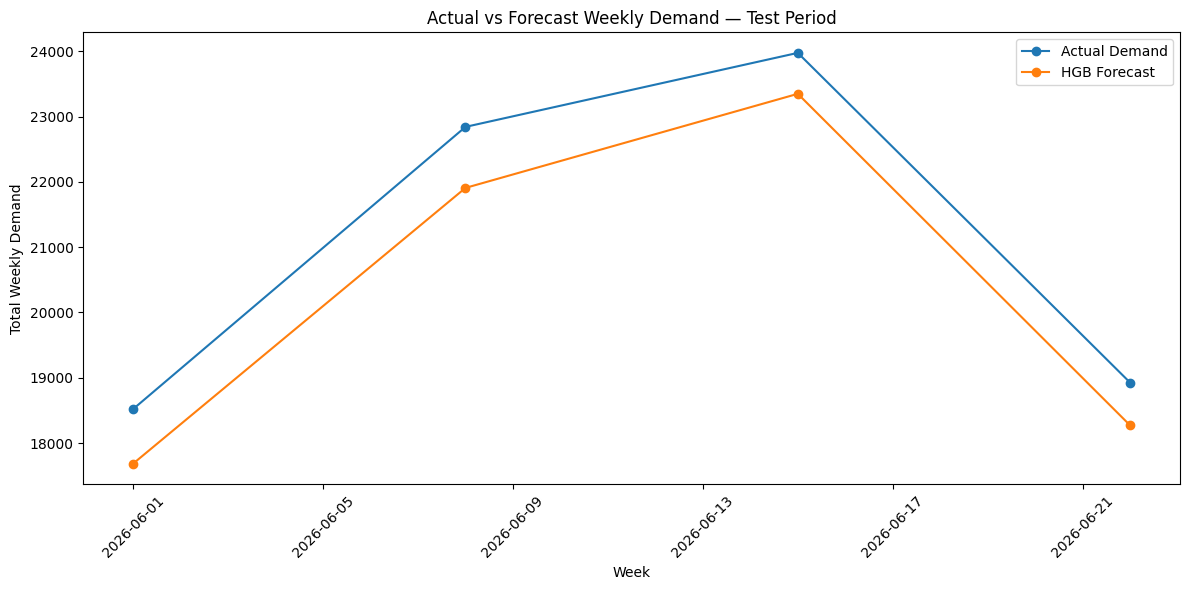

In [67]:
# ============================================================
# CELL 42 — Actual vs predicted total weekly demand
# ============================================================

weekly_actual = (
    test_results
    .groupby("week_start")["weekly_demand"]
    .sum()
)

weekly_forecast = (
    test_results
    .groupby("week_start")["forecast"]
    .sum()
)

plt.figure(figsize=(12, 6))

plt.plot(
    weekly_actual.index,
    weekly_actual.values,
    marker="o",
    label="Actual Demand"
)

plt.plot(
    weekly_forecast.index,
    weekly_forecast.values,
    marker="o",
    label="HGB Forecast"
)

plt.title(
    "Actual vs Forecast Weekly Demand — Test Period"
)

plt.xlabel("Week")
plt.ylabel("Total Weekly Demand")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

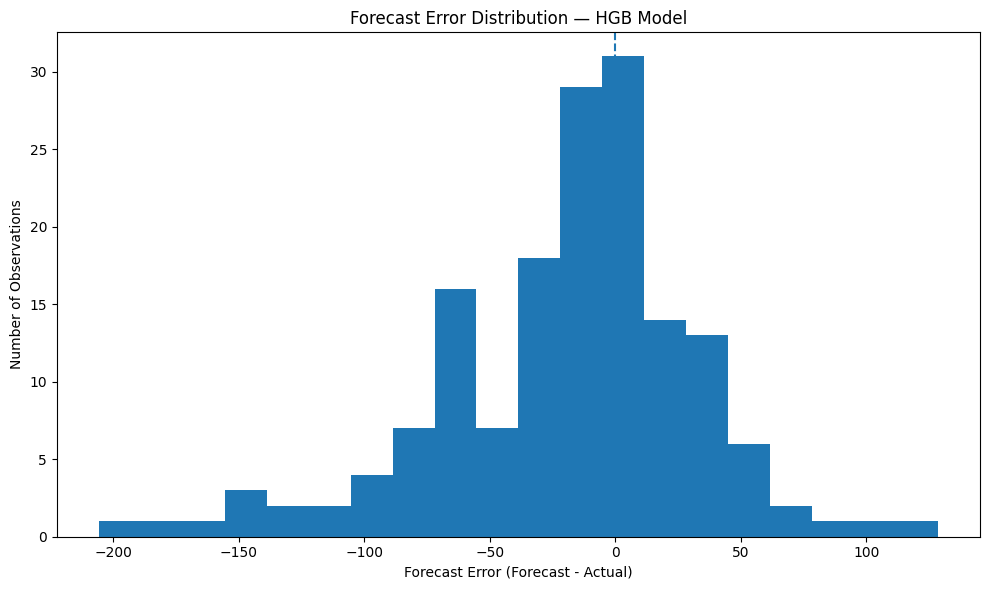

In [68]:
# ============================================================
# CELL 43 — Forecast error distribution
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    test_results["error"],
    bins=20
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Forecast Error Distribution — HGB Model"
)

plt.xlabel(
    "Forecast Error (Forecast - Actual)"
)

plt.ylabel(
    "Number of Observations"
)

plt.tight_layout()

plt.show()

In [71]:
# ============================================================
# DIAGNOSTIC — Check encoded feature structure
# ============================================================

print("X_validation_encoded type:")
print(type(X_validation_encoded))

print("\nEncoded shape:")
print(X_validation_encoded.shape)

print("\nOriginal feature count:")
print(len(feature_columns_v1))

print("\nObjects related to preprocessing:")
print([
    name for name in globals()
    if any(
        word in name.lower()
        for word in ["preprocess", "transform", "encoder"]
    )
])

X_validation_encoded type:
<class 'numpy.ndarray'>

Encoded shape:
(160, 77)

Original feature count:
31

Objects related to preprocessing:
['ColumnTransformer', 'OneHotEncoder', 'preprocessor']


In [73]:
# ============================================================
# CELL 44 — HGB Feature Importance
# ============================================================

from sklearn.inspection import permutation_importance

print("Calculating permutation feature importance...")

importance_result = permutation_importance(
    hgb_model,
    X_validation_encoded,
    y_validation,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

# Get the actual encoded feature names from the fitted preprocessor
encoded_feature_names = preprocessor.get_feature_names_out()

print("Encoded feature count:", len(encoded_feature_names))
print("Importance count:", len(importance_result.importances_mean))

# Create feature importance table
feature_importance = pd.DataFrame({
    "feature": encoded_feature_names,
    "importance_mean": importance_result.importances_mean,
    "importance_std": importance_result.importances_std
})

feature_importance = (
    feature_importance
    .sort_values(
        "importance_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nTOP 20 FEATURES")
print("=" * 60)

display(
    feature_importance.head(20).round(5)
)

Calculating permutation feature importance...
Encoded feature count: 77
Importance count: 77

TOP 20 FEATURES


,feature,importance_mean,importance_std
0,numeric__rolling_mean_13_week,59.37188,3.86960
1,numeric__rolling_mean_8_week,38.12519,1.66821
2,numeric__rolling_mean_4_week,26.59109,2.57603
3,numeric__lag_1_week,23.51928,2.35023
4,numeric__lag_4_week,3.40819,0.61797
5,numeric__lag_2_week,0.73052,0.30575
6,numeric__demand_trend_4_13,0.58721,0.17879
7,categorical__sku_id_SKU011,0.43812,0.07545
8,categorical__sku_id_SKU008,0.20192,0.04248
9,categorical__sku_id_SKU003,0.17953,0.02525


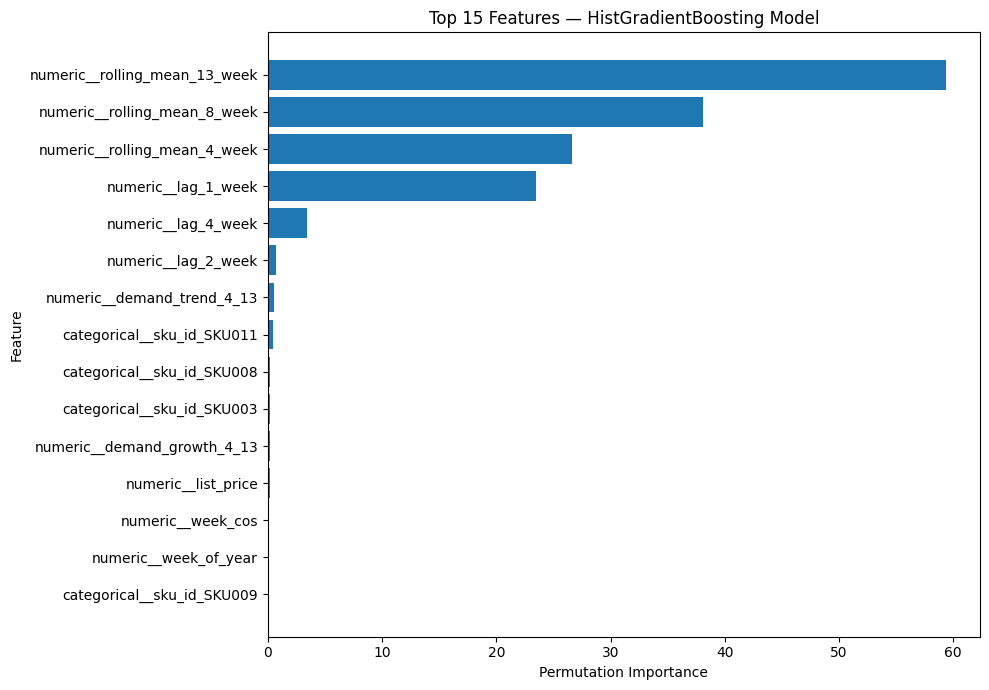

In [75]:
# ============================================================
# CELL 45 — Top Feature Importance Visualization
# ============================================================

top_features = (
    feature_importance
    .head(15)
    .sort_values("importance_mean")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance_mean"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title(
    "Top 15 Features — HistGradientBoosting Model"
)

plt.tight_layout()

plt.show()

In [76]:
# ============================================================
# CELL 46 — Aggregate Feature Importance
# ============================================================

feature_importance_grouped = feature_importance.copy()

def group_feature(feature):
    feature = feature.lower()

    if "rolling_mean" in feature:
        return "Rolling Demand"
    elif "rolling_std" in feature:
        return "Demand Volatility"
    elif "lag_" in feature:
        return "Lag Demand"
    elif "demand_trend" in feature:
        return "Demand Trend"
    elif "demand_growth" in feature:
        return "Demand Growth"
    elif "promo" in feature:
        return "Promotion"
    elif "price" in feature:
        return "Price"
    elif "week" in feature or "month" in feature or "quarter" in feature:
        return "Calendar"
    elif "sku_id" in feature:
        return "SKU Identity"
    elif "category" in feature or "subcategory" in feature:
        return "Product Category"
    else:
        return "Other"

feature_importance_grouped["feature_group"] = (
    feature_importance_grouped["feature"]
    .apply(group_feature)
)

grouped_importance = (
    feature_importance_grouped
    .groupby("feature_group")["importance_mean"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("AGGREGATED FEATURE IMPORTANCE")
print("=" * 60)

display(
    grouped_importance.round(3)
)

AGGREGATED FEATURE IMPORTANCE


,feature_group,importance_mean
0,Rolling Demand,124.088
1,Lag Demand,27.072
2,SKU Identity,0.634
3,Demand Trend,0.479
4,Demand Growth,0.164
5,Calendar,0.155
6,Price,0.153
7,Product Category,0.007
8,Other,0.000
9,Promotion,0.000


In [77]:
# ============================================================
# CELL 47 — Clean Feature Group Importance
# ============================================================

# Keep the original permutation importance values
grouped_importance_clean = (
    feature_importance_grouped
    .groupby("feature_group")
    .agg(
        importance_mean=("importance_mean", "sum"),
        feature_count=("feature", "count")
    )
    .reset_index()
)

# Separate positive and negative contributions
grouped_importance_clean["positive_importance"] = (
    feature_importance_grouped
    .assign(
        positive=lambda x: x["importance_mean"].clip(lower=0)
    )
    .groupby("feature_group")["positive"]
    .sum()
    .reindex(
        grouped_importance_clean["feature_group"]
    )
    .values
)

grouped_importance_clean["negative_importance"] = (
    feature_importance_grouped
    .assign(
        negative=lambda x: x["importance_mean"].clip(upper=0)
    )
    .groupby("feature_group")["negative"]
    .sum()
    .reindex(
        grouped_importance_clean["feature_group"]
    )
    .values
)

grouped_importance_clean = (
    grouped_importance_clean
    .sort_values(
        "positive_importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("CLEAN FEATURE GROUP IMPORTANCE")
print("=" * 70)

display(
    grouped_importance_clean.round(4)
)

CLEAN FEATURE GROUP IMPORTANCE


,feature_group,importance_mean,feature_count,positive_importance,negative_importance
0,Rolling Demand,124.0882,3,124.0882,0.0000
1,Lag Demand,27.0719,5,27.6580,-0.5861
2,SKU Identity,0.6341,40,0.9535,-0.3194
3,Demand Trend,0.4788,2,0.5872,-0.1084
4,Calendar,0.1553,8,0.1852,-0.0300
5,Demand Growth,0.1640,1,0.1640,0.0000
6,Price,0.1528,1,0.1528,0.0000
7,Product Category,0.0065,9,0.0262,-0.0197
8,Demand Volatility,-0.3653,2,0.0000,-0.3653
9,Other,0.0000,1,0.0000,0.0000


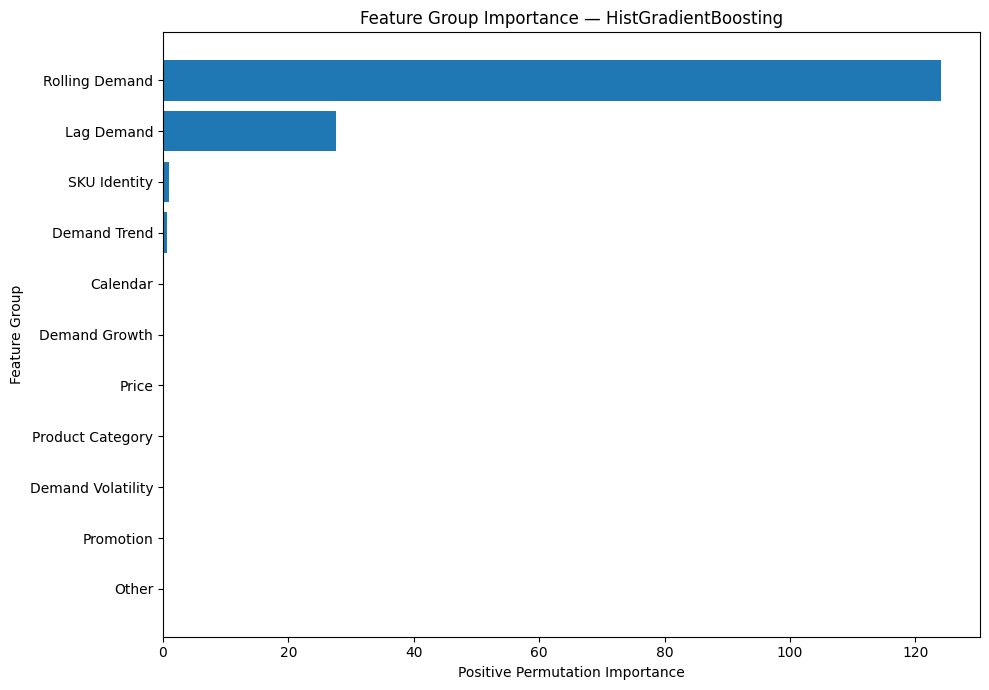

In [78]:
# ============================================================
# CELL 48 — Feature Group Importance Visualization
# ============================================================

plot_data = (
    grouped_importance_clean
    .sort_values("positive_importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["feature_group"],
    plot_data["positive_importance"]
)

plt.xlabel("Positive Permutation Importance")
plt.ylabel("Feature Group")
plt.title(
    "Feature Group Importance — HistGradientBoosting"
)

plt.tight_layout()

plt.show()

In [79]:
# ============================================================
# CELL 49 — SKU-level test performance
# ============================================================

sku_performance = (
    test_results
    .groupby("sku_id")
    .apply(
        lambda x: pd.Series({
            "actual_demand": x["weekly_demand"].sum(),
            "forecast_demand": x["forecast"].sum(),
            "WAPE": calculate_wape(
                x["weekly_demand"],
                x["forecast"]
            ),
            "Bias": calculate_bias(
                x["weekly_demand"],
                x["forecast"]
            ),
            "MAE": calculate_mae(
                x["weekly_demand"],
                x["forecast"]
            )
        })
    )
    .reset_index()
)

sku_performance["WAPE"] *= 100
sku_performance["Bias"] *= 100

sku_performance = sku_performance.sort_values(
    "WAPE"
).reset_index(drop=True)

print("SKU-LEVEL TEST PERFORMANCE")
print("=" * 70)

display(
    sku_performance.round(2)
)

SKU-LEVEL TEST PERFORMANCE


C:\Users\user\AppData\Local\Temp\ipykernel_7812\958201614.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,sku_id,actual_demand,forecast_demand,WAPE,Bias,MAE
0,SKU028,2400.0,2423.23,2.15,0.97,12.91
1,SKU021,3086.0,3014.95,2.45,-2.30,18.93
2,SKU004,1585.0,1594.72,3.05,0.61,12.10
3,SKU018,2998.0,2902.09,3.20,-3.20,23.98
4,SKU037,857.0,864.45,3.42,0.87,7.33
5,SKU034,2703.0,2706.77,3.88,0.14,26.25
6,SKU012,1885.0,1826.89,4.21,-3.08,19.83
7,SKU009,664.0,639.67,4.26,-3.66,7.07
8,SKU005,3167.0,3051.22,4.30,-3.66,34.02
9,SKU017,1940.0,1906.40,4.31,-1.73,20.92


In [80]:
# ============================================================
# CELL 50 — Best and Worst SKUs
# ============================================================

print("TOP 10 BEST-PERFORMING SKUs")
print("=" * 70)

display(
    sku_performance[
        ["sku_id", "WAPE", "Bias", "MAE"]
    ]
    .head(10)
    .round(2)
)

print("\nTOP 10 WORST-PERFORMING SKUs")
print("=" * 70)

display(
    sku_performance[
        ["sku_id", "WAPE", "Bias", "MAE"]
    ]
    .sort_values("WAPE", ascending=False)
    .head(10)
    .round(2)
)

TOP 10 BEST-PERFORMING SKUs


,sku_id,WAPE,Bias,MAE
0,SKU028,2.15,0.97,12.91
1,SKU021,2.45,-2.30,18.93
2,SKU004,3.05,0.61,12.10
3,SKU018,3.20,-3.20,23.98
4,SKU037,3.42,0.87,7.33
5,SKU034,3.88,0.14,26.25
6,SKU012,4.21,-3.08,19.83
7,SKU009,4.26,-3.66,7.07
8,SKU005,4.30,-3.66,34.02
9,SKU017,4.31,-1.73,20.92



TOP 10 WORST-PERFORMING SKUs


,sku_id,WAPE,Bias,MAE
39,SKU003,16.41,-8.86,18.54
38,SKU006,15.88,5.47,19.65
37,SKU033,14.14,-7.35,25.74
36,SKU008,12.69,-12.69,122.94
35,SKU011,12.49,-10.33,118.39
34,SKU024,11.57,-6.11,47.92
33,SKU026,11.53,-11.53,106.74
32,SKU031,11.31,-11.31,20.56
31,SKU022,11.28,10.56,55.61
30,SKU020,10.73,-10.73,98.67


In [81]:
# ============================================================
# CELL 51 — Diagnose difficult SKUs
# ============================================================

# Calculate demand statistics from the weekly historical dataset
sku_diagnostics = (
    weekly
    .groupby("sku_id")
    .agg(
        historical_mean_demand=("weekly_demand", "mean"),
        historical_std_demand=("weekly_demand", "std"),
        historical_min_demand=("weekly_demand", "min"),
        historical_max_demand=("weekly_demand", "max"),
        historical_weeks=("weekly_demand", "count")
    )
    .reset_index()
)

# Calculate coefficient of variation
sku_diagnostics["demand_cv"] = (
    sku_diagnostics["historical_std_demand"]
    / sku_diagnostics["historical_mean_demand"]
)

# Combine with test performance
sku_diagnostics = sku_diagnostics.merge(
    sku_performance[
        [
            "sku_id",
            "WAPE",
            "Bias",
            "MAE"
        ]
    ],
    on="sku_id",
    how="left"
)

# Sort by forecasting error
sku_diagnostics = (
    sku_diagnostics
    .sort_values("WAPE", ascending=False)
    .reset_index(drop=True)
)

print("SKU FORECASTING DIAGNOSTICS")
print("=" * 80)

display(
    sku_diagnostics.round(3)
)

SKU FORECASTING DIAGNOSTICS


,sku_id,historical_mean_demand,historical_std_demand,historical_min_demand,historical_max_demand,historical_weeks,demand_cv,WAPE,Bias,MAE
0,SKU003,83.922,15.255,60.0,139.0,77,0.182,16.406,-8.857,18.538
1,SKU006,98.727,14.697,67.0,153.0,77,0.149,15.879,5.469,19.650
2,SKU033,150.121,24.778,108.0,226.0,58,0.165,14.142,-7.347,25.738
3,SKU008,756.312,114.801,567.0,1185.0,77,0.152,12.690,-12.690,122.936
4,SKU011,769.440,106.938,571.0,1074.0,75,0.139,12.492,-10.325,118.389
5,SKU024,313.108,48.236,241.0,516.0,74,0.154,11.574,-6.106,47.916
6,SKU026,722.247,130.588,527.0,1441.0,77,0.181,11.533,-11.533,106.736
7,SKU031,140.638,35.596,96.0,365.0,69,0.253,11.312,-11.312,20.559
8,SKU022,410.442,57.490,296.0,609.0,77,0.140,11.279,10.565,55.607
9,SKU020,731.500,109.738,585.0,1054.0,72,0.150,10.731,-10.731,98.673


In [82]:
# ============================================================
# CELL 52 — Worst SKU diagnostic summary
# ============================================================

worst_skus = sku_diagnostics.head(10)

print("WORST 10 SKUs — DIAGNOSTIC SUMMARY")
print("=" * 80)

display(
    worst_skus[
        [
            "sku_id",
            "WAPE",
            "Bias",
            "MAE",
            "historical_mean_demand",
            "historical_std_demand",
            "demand_cv",
            "historical_weeks"
        ]
    ].round(3)
)

WORST 10 SKUs — DIAGNOSTIC SUMMARY


,sku_id,WAPE,Bias,MAE,historical_mean_demand,historical_std_demand,demand_cv,historical_weeks
0,SKU003,16.406,-8.857,18.538,83.922,15.255,0.182,77
1,SKU006,15.879,5.469,19.650,98.727,14.697,0.149,77
2,SKU033,14.142,-7.347,25.738,150.121,24.778,0.165,58
3,SKU008,12.690,-12.690,122.936,756.312,114.801,0.152,77
4,SKU011,12.492,-10.325,118.389,769.440,106.938,0.139,75
5,SKU024,11.574,-6.106,47.916,313.108,48.236,0.154,74
6,SKU026,11.533,-11.533,106.736,722.247,130.588,0.181,77
7,SKU031,11.312,-11.312,20.559,140.638,35.596,0.253,69
8,SKU022,11.279,10.565,55.607,410.442,57.490,0.140,77
9,SKU020,10.731,-10.731,98.673,731.500,109.738,0.150,72


In [83]:
# ============================================================
# CELL 53 — Weekly Test Error Analysis
# ============================================================

test_results = test_results.copy()

test_results["error"] = (
    test_results["forecast"] -
    test_results["weekly_demand"]
)

test_results["absolute_error"] = (
    test_results["error"].abs()
)

weekly_error_summary = (
    test_results
    .groupby("week_start")
    .agg(
        actual_demand=("weekly_demand", "sum"),
        forecast_demand=("forecast", "sum"),
        total_error=("error", "sum"),
        absolute_error=("absolute_error", "sum"),
        observations=("weekly_demand", "count")
    )
    .reset_index()
)

weekly_error_summary["WAPE"] = (
    weekly_error_summary["absolute_error"] /
    weekly_error_summary["actual_demand"] *
    100
)

weekly_error_summary["Bias"] = (
    weekly_error_summary["total_error"] /
    weekly_error_summary["actual_demand"] *
    100
)

print("WEEKLY TEST ERROR ANALYSIS")
print("=" * 80)

display(
    weekly_error_summary.round(2)
)

WEEKLY TEST ERROR ANALYSIS


,week_start,actual_demand,forecast_demand,total_error,absolute_error,observations,WAPE,Bias
0,2026-06-01,18520.0,17684.26,-835.74,1297.13,40,7.00,-4.51
1,2026-06-08,22843.0,21908.23,-934.77,1778.57,40,7.79,-4.09
2,2026-06-15,23977.0,23349.67,-627.33,1566.48,40,6.53,-2.62
3,2026-06-22,18925.0,18269.91,-655.09,1640.53,40,8.67,-3.46


In [84]:
# ============================================================
# CELL 54 — Error by SKU and test week
# ============================================================

error_matrix = (
    test_results
    .pivot_table(
        index="sku_id",
        columns="week_start",
        values="error"
    )
)

print("FORECAST ERROR MATRIX")
print("=" * 80)

display(
    error_matrix.round(2)
)

FORECAST ERROR MATRIX


week_start,2026-06-01,2026-06-08,2026-06-15,2026-06-22
sku_id,,,,
SKU001,49.94,1.48,43.29,17.35
SKU002,11.44,-41.00,-3.10,-11.14
SKU003,-7.33,-31.84,-17.93,17.06
SKU004,1.23,-19.34,22.25,5.58
SKU005,-58.52,-40.07,-27.34,10.14
SKU006,-16.98,28.29,-8.79,24.55
SKU007,-50.84,-23.03,64.09,-46.15
SKU008,-89.26,-72.18,-205.78,-124.53
SKU009,-6.37,-2.65,1.97,-17.28


In [85]:
print("HGB model object:")
print(type(hgb_model))

print("\nPreprocessor object:")
print(type(preprocessor))

print("\nFeature columns:")
print(len(feature_columns))
print(feature_columns)

HGB model object:
<class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingRegressor'>

Preprocessor object:
<class 'sklearn.compose._column_transformer.ColumnTransformer'>

Feature columns:
30
['lag_1_week', 'lag_2_week', 'lag_4_week', 'lag_8_week', 'lag_13_week', 'lag_26_week', 'rolling_mean_4_week', 'rolling_mean_8_week', 'rolling_mean_13_week', 'rolling_std_4_week', 'rolling_std_8_week', 'demand_trend_4_13', 'demand_trend_8_13', 'demand_growth_4_13', 'month', 'quarter', 'week_of_year', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'promo_days', 'holiday_days', 'promo_week', 'holiday_week', 'promo_demand_interaction', 'promo_intensity', 'holiday_promo_interaction', 'unit_cost', 'list_price']


In [86]:
# ============================================================
# CELL — SAVE FINAL HGB MODEL + PREPROCESSOR
# ============================================================

import os
import joblib

os.makedirs("../models", exist_ok=True)

model_bundle = {
    "model": hgb_model,
    "preprocessor": preprocessor,
    "feature_columns": feature_columns,

    "model_name": "HistGradientBoosting V2",
    "target": "weekly_demand",

    "original_feature_count": len(feature_columns),
    "encoded_feature_count": 77,

    "validation_wape": 0.060305,
    "validation_bias": -0.007555,
    "validation_mae": 24.859972,

    "test_wape": 0.0746,
    "test_bias": -0.0362,
    "test_mae": 39.27
}

model_path = "../models/demand_forecasting_hgb_v2.joblib"

joblib.dump(model_bundle, model_path)

print("=" * 60)
print("FINAL MODEL SAVED SUCCESSFULLY")
print("=" * 60)
print("Path:", model_path)
print("Model:", model_bundle["model_name"])
print("Features:", model_bundle["original_feature_count"])
print("Encoded features:", model_bundle["encoded_feature_count"])
print(f"Validation WAPE: {model_bundle['validation_wape']:.2%}")
print(f"Test WAPE: {model_bundle['test_wape']:.2%}")
print(f"Test Bias: {model_bundle['test_bias']:.2%}")
print(f"Test MAE: {model_bundle['test_mae']:.2f}")

FINAL MODEL SAVED SUCCESSFULLY
Path: ../models/demand_forecasting_hgb_v2.joblib
Model: HistGradientBoosting V2
Features: 30
Encoded features: 77
Validation WAPE: 6.03%
Test WAPE: 7.46%
Test Bias: -3.62%
Test MAE: 39.27


In [87]:
# ============================================================
# VERIFY SAVED MODEL
# ============================================================

import joblib

loaded_bundle = joblib.load(
    "../models/demand_forecasting_hgb_v2.joblib"
)

print("Model loaded successfully!")
print("Model type:", type(loaded_bundle["model"]))
print("Preprocessor type:", type(loaded_bundle["preprocessor"]))
print("Feature count:", len(loaded_bundle["feature_columns"]))
print("Feature list:")
print(loaded_bundle["feature_columns"])

Model loaded successfully!
Model type: <class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingRegressor'>
Preprocessor type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Feature count: 30
Feature list:
['lag_1_week', 'lag_2_week', 'lag_4_week', 'lag_8_week', 'lag_13_week', 'lag_26_week', 'rolling_mean_4_week', 'rolling_mean_8_week', 'rolling_mean_13_week', 'rolling_std_4_week', 'rolling_std_8_week', 'demand_trend_4_13', 'demand_trend_8_13', 'demand_growth_4_13', 'month', 'quarter', 'week_of_year', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'promo_days', 'holiday_days', 'promo_week', 'holiday_week', 'promo_demand_interaction', 'promo_intensity', 'holiday_promo_interaction', 'unit_cost', 'list_price']


In [101]:
# ============================================================
# CELL — FINAL CORRECTED FORECAST FUNCTION
# ============================================================

import joblib

# Load saved model bundle
model_bundle = joblib.load(
    "../models/demand_forecasting_hgb_v2.joblib"
)

final_model = model_bundle["model"]
final_preprocessor = model_bundle["preprocessor"]

# Get EXACT input schema used when preprocessor was fitted
preprocessor_features = list(
    final_preprocessor.feature_names_in_
)

print("=" * 60)
print("FINAL FORECAST PIPELINE")
print("=" * 60)
print("Preprocessor expects:", len(preprocessor_features), "features")
print(preprocessor_features)


def generate_forecast(input_df):

    # Check required columns
    missing_features = [
        col
        for col in preprocessor_features
        if col not in input_df.columns
    ]

    if missing_features:
        raise ValueError(
            f"Missing required features: {missing_features}"
        )

    # Use EXACTLY the columns and order used during training
    X = input_df[preprocessor_features].copy()

    # Preprocess
    X_encoded = final_preprocessor.transform(X)

    # Predict
    predictions = final_model.predict(X_encoded)

    # Build output
    result = input_df[
        ["sku_id", "week_start"]
    ].copy()

    result["forecast_demand"] = predictions

    return result


print("\nFunction created successfully.")

FINAL FORECAST PIPELINE
Preprocessor expects: 31 features
['lag_1_week', 'lag_2_week', 'lag_4_week', 'lag_8_week', 'lag_13_week', 'rolling_mean_4_week', 'rolling_mean_8_week', 'rolling_mean_13_week', 'rolling_std_4_week', 'rolling_std_8_week', 'demand_trend_4_13', 'demand_trend_8_13', 'demand_growth_4_13', 'month', 'quarter', 'week_of_year', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'promo_days', 'holiday_days', 'promo_week', 'holiday_week', 'promo_demand_interaction', 'promo_intensity', 'holiday_promo_interaction', 'sku_id', 'category', 'subcategory', 'list_price']

Function created successfully.


In [104]:
# ============================================================
# CELL — TEST FINAL FORECAST PIPELINE
# ============================================================

test_forecast = generate_forecast(test_ml)

print("=" * 60)
print("FORECAST FUNCTION TEST")
print("=" * 60)

display(test_forecast.head(20))

print("\nForecast rows:", len(test_forecast))
print("SKUs:", test_forecast["sku_id"].nunique())

print(
    "Date range:",
    test_forecast["week_start"].min(),
    "→",
    test_forecast["week_start"].max()
)

FORECAST FUNCTION TEST


,sku_id,week_start,forecast_demand
2789,SKU001,2026-06-01,458.941901
2790,SKU002,2026-06-01,194.442834
2791,SKU003,2026-06-01,94.673062
2792,SKU004,2026-06-01,329.230192
2793,SKU005,2026-06-01,686.481493
2794,SKU006,2026-06-01,104.020780
2795,SKU007,2026-06-01,698.155884
2796,SKU008,2026-06-01,746.743289
2797,SKU009,2026-06-01,142.627262
2798,SKU010,2026-06-01,411.287608



Forecast rows: 156
SKUs: 39
Date range: 2026-06-01 00:00:00 → 2026-06-22 00:00:00


In [106]:
# ============================================================
# FIND THE ORIGINAL 160-ROW TEST DATASET
# ============================================================

import pandas as pd

print("DataFrames in current notebook matching test structure:")
print("=" * 60)

# Take a snapshot of globals before iterating
all_objects = list(globals().items())

for name, obj in all_objects:
    if isinstance(obj, pd.DataFrame):
        if (
            "sku_id" in obj.columns
            and "week_start" in obj.columns
            and len(obj) in [160, 156]
        ):
            print(
                f"{name:35s} "
                f"shape={obj.shape} "
                f"SKUs={obj['sku_id'].nunique()} "
                f"dates={obj['week_start'].min()} → {obj['week_start'].max()}"
            )

DataFrames in current notebook matching test structure:
test_df                             shape=(160, 39) SKUs=40 dates=2026-06-01 00:00:00 → 2026-06-22 00:00:00
evaluation                          shape=(160, 4) SKUs=40 dates=2026-06-01 00:00:00 → 2026-06-22 00:00:00
validation_df                       shape=(160, 39) SKUs=40 dates=2026-05-04 00:00:00 → 2026-05-25 00:00:00
dataset                             shape=(160, 39) SKUs=40 dates=2026-06-01 00:00:00 → 2026-06-22 00:00:00
validation_ml                       shape=(156, 39) SKUs=39 dates=2026-05-04 00:00:00 → 2026-05-25 00:00:00
test_ml                             shape=(156, 39) SKUs=39 dates=2026-06-01 00:00:00 → 2026-06-22 00:00:00
validation_ml_v1                    shape=(160, 39) SKUs=40 dates=2026-05-04 00:00:00 → 2026-05-25 00:00:00
test_ml_v1                          shape=(160, 39) SKUs=40 dates=2026-06-01 00:00:00 → 2026-06-22 00:00:00
validation_results                  shape=(160, 4) SKUs=40 dates=2026-05-04 00:00

In [107]:
# ============================================================
# FINAL REUSABLE FORECAST PIPELINE — 160 ROW TEST
# ============================================================

# Use the original complete test dataset
final_test_input = test_ml_v1.copy()

# Generate forecasts
final_test_forecast = generate_forecast(final_test_input)

print("=" * 60)
print("FINAL REUSABLE FORECAST PIPELINE")
print("=" * 60)

print("\nForecast sample:")
display(final_test_forecast.head(20))

print("\nRows:", len(final_test_forecast))
print("SKUs:", final_test_forecast["sku_id"].nunique())

print(
    "Date range:",
    final_test_forecast["week_start"].min(),
    "→",
    final_test_forecast["week_start"].max()
)

print("\nMissing forecasts:")
print(final_test_forecast["forecast_demand"].isna().sum())

FINAL REUSABLE FORECAST PIPELINE

Forecast sample:


,sku_id,week_start,forecast_demand
2789,SKU001,2026-06-01,458.941901
2790,SKU002,2026-06-01,194.442834
2791,SKU003,2026-06-01,94.673062
2792,SKU004,2026-06-01,329.230192
2793,SKU005,2026-06-01,686.481493
2794,SKU006,2026-06-01,104.020780
2795,SKU007,2026-06-01,698.155884
2796,SKU008,2026-06-01,746.743289
2797,SKU009,2026-06-01,142.627262
2798,SKU010,2026-06-01,411.287608



Rows: 160
SKUs: 40
Date range: 2026-06-01 00:00:00 → 2026-06-22 00:00:00

Missing forecasts:
0


In [108]:
# ============================================================
# COMPARE REUSABLE PIPELINE WITH FINAL TEST RESULTS
# ============================================================

comparison = test_results[
    ["sku_id", "week_start", "forecast"]
].merge(
    final_test_forecast,
    on=["sku_id", "week_start"],
    how="inner"
)

comparison["forecast_difference"] = (
    comparison["forecast"]
    - comparison["forecast_demand"]
)

print("=" * 60)
print("FORECAST CONSISTENCY CHECK")
print("=" * 60)

print("Common rows:", len(comparison))

print(
    "Maximum absolute difference:",
    comparison["forecast_difference"].abs().max()
)

display(comparison.head(20))

FORECAST CONSISTENCY CHECK
Common rows: 160
Maximum absolute difference: 0.0


,sku_id,week_start,forecast,forecast_demand,forecast_difference
0,SKU001,2026-06-01,458.941901,458.941901,0.0
1,SKU002,2026-06-01,194.442834,194.442834,0.0
2,SKU003,2026-06-01,94.673062,94.673062,0.0
3,SKU004,2026-06-01,329.230192,329.230192,0.0
4,SKU005,2026-06-01,686.481493,686.481493,0.0
5,SKU006,2026-06-01,104.020780,104.020780,0.0
6,SKU007,2026-06-01,698.155884,698.155884,0.0
7,SKU008,2026-06-01,746.743289,746.743289,0.0
8,SKU009,2026-06-01,142.627262,142.627262,0.0
9,SKU010,2026-06-01,411.287608,411.287608,0.0


In [109]:
# ============================================================
# STEP 1 — SAVE FINAL TEST FORECASTS
# ============================================================

final_predictions = final_test_forecast.copy()

# Clean column names for the final deliverable
final_predictions = final_predictions[
    ["sku_id", "week_start", "forecast_demand"]
].copy()

# Rename for a business-friendly output
final_predictions = final_predictions.rename(
    columns={"forecast_demand": "forecast_weekly_demand"}
)

# Round forecasts to 2 decimals
final_predictions["forecast_weekly_demand"] = (
    final_predictions["forecast_weekly_demand"].round(2)
)

# Sort
final_predictions = final_predictions.sort_values(
    ["week_start", "sku_id"]
).reset_index(drop=True)

# Save
final_predictions_path = "../data/processed/final_test_forecasts.csv"

final_predictions.to_csv(
    final_predictions_path,
    index=False
)

print("=" * 60)
print("FINAL PREDICTION FILE CREATED")
print("=" * 60)

print("File:", final_predictions_path)
print("Rows:", len(final_predictions))
print("SKUs:", final_predictions["sku_id"].nunique())
print(
    "Weeks:",
    final_predictions["week_start"].nunique()
)

print("\nDate range:")
print(
    final_predictions["week_start"].min(),
    "→",
    final_predictions["week_start"].max()
)

print("\nMissing forecasts:")
print(
    final_predictions["forecast_weekly_demand"].isna().sum()
)

print("\nSample:")
display(final_predictions.head(20))

FINAL PREDICTION FILE CREATED
File: ../data/processed/final_test_forecasts.csv
Rows: 160
SKUs: 40
Weeks: 4

Date range:
2026-06-01 00:00:00 → 2026-06-22 00:00:00

Missing forecasts:
0

Sample:


,sku_id,week_start,forecast_weekly_demand
0,SKU001,2026-06-01,458.94
1,SKU002,2026-06-01,194.44
2,SKU003,2026-06-01,94.67
3,SKU004,2026-06-01,329.23
4,SKU005,2026-06-01,686.48
5,SKU006,2026-06-01,104.02
6,SKU007,2026-06-01,698.16
7,SKU008,2026-06-01,746.74
8,SKU009,2026-06-01,142.63
9,SKU010,2026-06-01,411.29


In [110]:
# ============================================================
# STEP 2 — SAVE FINAL MODEL + PREPROCESSOR
# ============================================================

import os
import joblib

# Create model directory if it doesn't exist
model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

# Paths
model_path = os.path.join(
    model_dir,
    "hgb_demand_forecasting_model.joblib"
)

preprocessor_path = os.path.join(
    model_dir,
    "hgb_demand_forecasting_preprocessor.joblib"
)

features_path = os.path.join(
    model_dir,
    "hgb_demand_forecasting_features.joblib"
)

# Save trained model
joblib.dump(final_model, model_path)

# Save fitted preprocessor
joblib.dump(final_preprocessor, preprocessor_path)

# Save exact feature list used by the model
joblib.dump(final_feature_columns, features_path)

print("=" * 60)
print("FINAL MODEL ARTIFACTS SAVED")
print("=" * 60)

print("\nModel:")
print(model_path)

print("\nPreprocessor:")
print(preprocessor_path)

print("\nFeature list:")
print(features_path)

print("\nModel type:")
print(type(final_model))

print("\nPreprocessor type:")
print(type(final_preprocessor))

print("\nFeature count:")
print(len(final_feature_columns))

print("\nFiles exist:")
print("Model:", os.path.exists(model_path))
print("Preprocessor:", os.path.exists(preprocessor_path))
print("Features:", os.path.exists(features_path))

FINAL MODEL ARTIFACTS SAVED

Model:
../models\hgb_demand_forecasting_model.joblib

Preprocessor:
../models\hgb_demand_forecasting_preprocessor.joblib

Feature list:
../models\hgb_demand_forecasting_features.joblib

Model type:
<class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingRegressor'>

Preprocessor type:
<class 'sklearn.compose._column_transformer.ColumnTransformer'>

Feature count:
30

Files exist:
Model: True
Preprocessor: True
Features: True


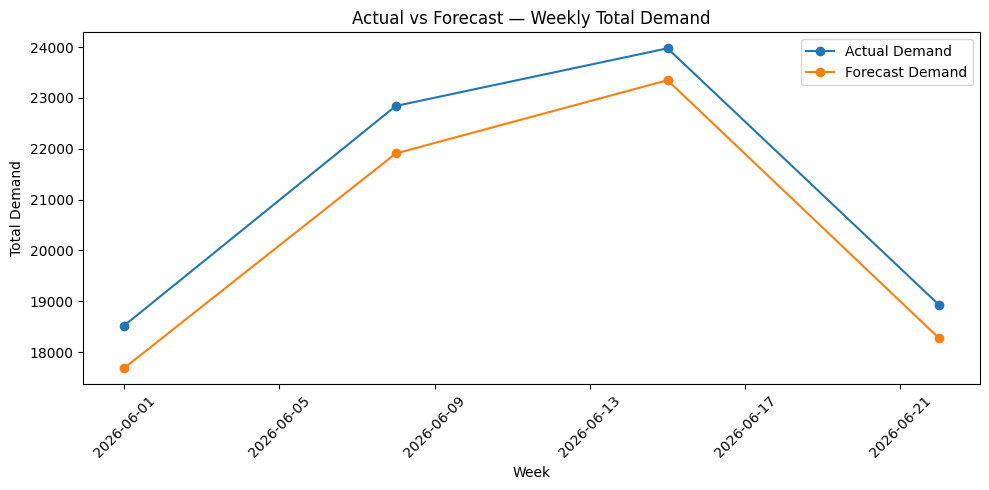

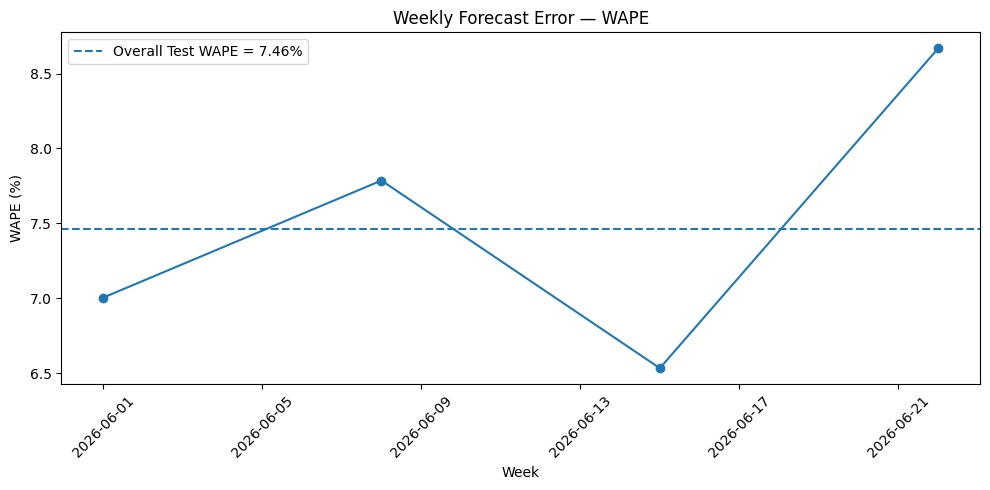

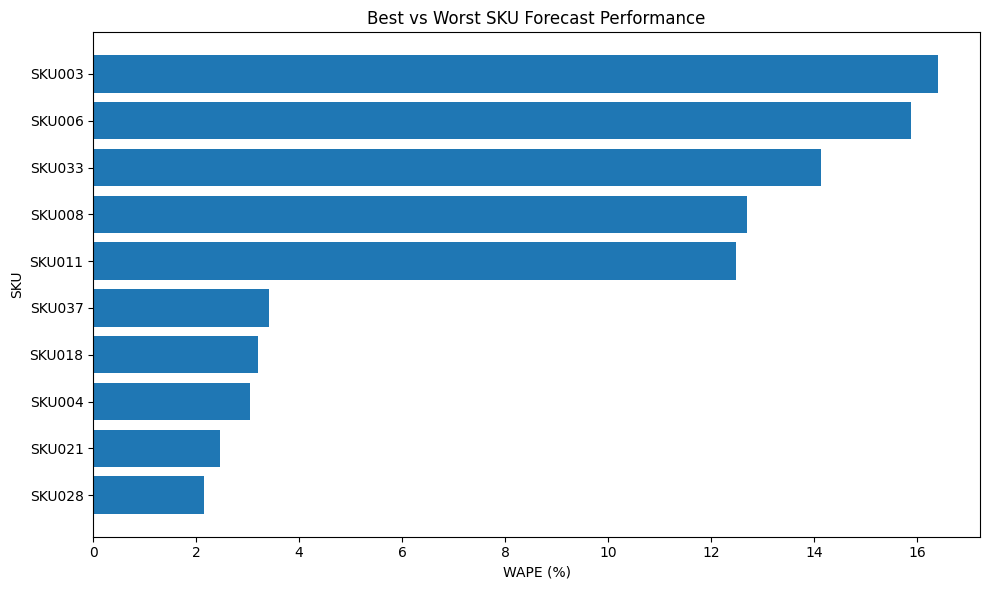

FINAL VISUALIZATIONS CREATED

1. Actual vs Forecast:
../reports/figures\actual_vs_forecast_weekly.png

2. Weekly WAPE:
../reports/figures\weekly_wape.png

3. Best vs Worst SKU Performance:
../reports/figures\best_vs_worst_sku_performance.png

4. Feature Group Importance:
../reports/figures\feature_group_importance.png

All visualization files exist:
True


In [113]:
# ============================================================
# STEP 3 — FINAL MODEL EVALUATION VISUALIZATIONS
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Create visualization directory
viz_dir = "../reports/figures"
os.makedirs(viz_dir, exist_ok=True)

# ------------------------------------------------------------
# Prepare test results
# ------------------------------------------------------------

plot_df = test_results.copy()

plot_df["week_start"] = pd.to_datetime(plot_df["week_start"])

# ============================================================
# 1. ACTUAL VS FORECAST — TOTAL WEEKLY DEMAND
# ============================================================

weekly_actual = (
    plot_df.groupby("week_start")["weekly_demand"]
    .sum()
)

weekly_forecast = (
    plot_df.groupby("week_start")["forecast"]
    .sum()
)

plt.figure(figsize=(10, 5))

plt.plot(
    weekly_actual.index,
    weekly_actual.values,
    marker="o",
    label="Actual Demand"
)

plt.plot(
    weekly_forecast.index,
    weekly_forecast.values,
    marker="o",
    label="Forecast Demand"
)

plt.title("Actual vs Forecast — Weekly Total Demand")
plt.xlabel("Week")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

actual_forecast_path = os.path.join(
    viz_dir,
    "actual_vs_forecast_weekly.png"
)

plt.savefig(
    actual_forecast_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 2. WEEKLY WAPE
# ============================================================

weekly_metrics = (
    plot_df.groupby("week_start")
    .apply(
        lambda x: pd.Series({
            "WAPE": (
                x["absolute_error"].sum()
                / x["weekly_demand"].sum()
            ) * 100,
            "Bias": (
                x["error"].sum()
                / x["weekly_demand"].sum()
            ) * 100
        }),
        include_groups=False
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    weekly_metrics["week_start"],
    weekly_metrics["WAPE"],
    marker="o"
)

plt.axhline(
    y=7.46,
    linestyle="--",
    label="Overall Test WAPE = 7.46%"
)

plt.title("Weekly Forecast Error — WAPE")
plt.xlabel("Week")
plt.ylabel("WAPE (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

weekly_wape_path = os.path.join(
    viz_dir,
    "weekly_wape.png"
)

plt.savefig(
    weekly_wape_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 3. SKU PERFORMANCE — BEST VS WORST
# ============================================================

sku_performance = (
    plot_df.groupby("sku_id")
    .apply(
        lambda x: pd.Series({
            "WAPE": (
                x["absolute_error"].sum()
                / x["weekly_demand"].sum()
            ) * 100
        }),
        include_groups=False
    )
    .reset_index()
    .sort_values("WAPE")
)

best_5 = sku_performance.head(5)
worst_5 = sku_performance.tail(5)

comparison = pd.concat(
    [best_5, worst_5]
)

plt.figure(figsize=(10, 6))

plt.barh(
    comparison["sku_id"],
    comparison["WAPE"]
)

plt.title("Best vs Worst SKU Forecast Performance")
plt.xlabel("WAPE (%)")
plt.ylabel("SKU")

plt.tight_layout()

sku_performance_path = os.path.join(
    viz_dir,
    "best_vs_worst_sku_performance.png"
)

plt.savefig(
    sku_performance_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# SUMMARY
# ============================================================

print("=" * 60)
print("FINAL VISUALIZATIONS CREATED")
print("=" * 60)

print("\n1. Actual vs Forecast:")
print(actual_forecast_path)

print("\n2. Weekly WAPE:")
print(weekly_wape_path)

print("\n3. Best vs Worst SKU Performance:")
print(sku_performance_path)

print("\n4. Feature Group Importance:")
print(feature_importance_path)

print("\nAll visualization files exist:")
print(
    all([
        os.path.exists(actual_forecast_path),
        os.path.exists(weekly_wape_path),
        os.path.exists(sku_performance_path),
        os.path.exists(feature_importance_path)
    ])
)

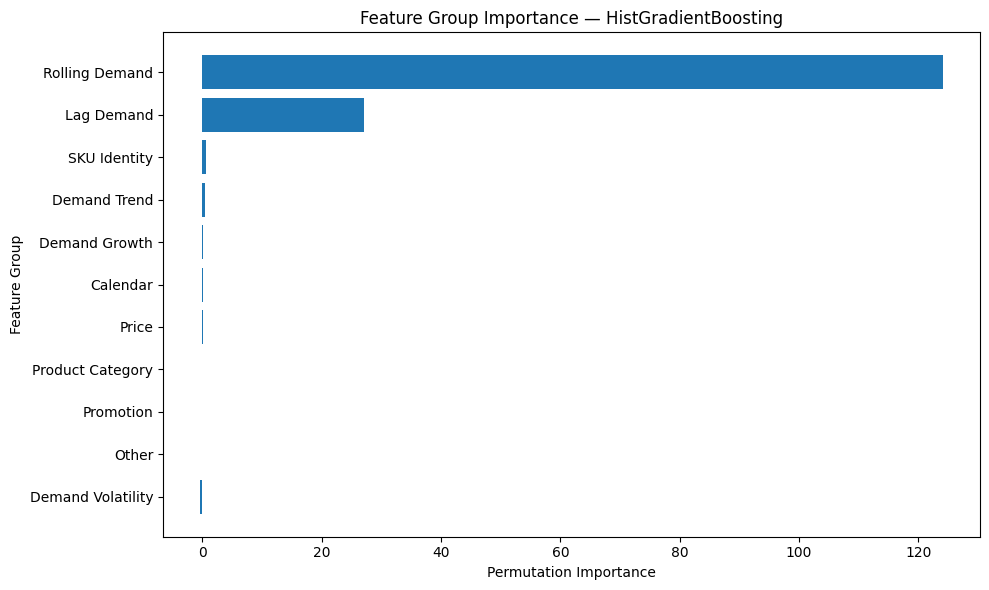

FEATURE GROUP IMPORTANCE CREATED

Saved to:
../reports/figures\feature_group_importance.png

Feature group importance:


,feature_group,importance_mean
0,Rolling Demand,124.0882
1,Lag Demand,27.0719
2,SKU Identity,0.6341
3,Demand Trend,0.4788
4,Demand Growth,0.1640
5,Calendar,0.1553
6,Price,0.1528
7,Product Category,0.0065
8,Other,0.0000
9,Promotion,0.0000


In [114]:
# ============================================================
# STEP 3B — FEATURE GROUP IMPORTANCE VISUALIZATION
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import os

# Exact feature-group importance from the final HGB model
feature_group_importance = pd.DataFrame({
    "feature_group": [
        "Rolling Demand",
        "Lag Demand",
        "SKU Identity",
        "Demand Trend",
        "Demand Growth",
        "Calendar",
        "Price",
        "Product Category",
        "Other",
        "Promotion",
        "Demand Volatility"
    ],
    "importance_mean": [
        124.0882,
        27.0719,
        0.6341,
        0.4788,
        0.1640,
        0.1553,
        0.1528,
        0.0065,
        0.0000,
        0.0000,
        -0.3653
    ]
})

# Sort for horizontal bar chart
importance_plot_df = (
    feature_group_importance
    .sort_values("importance_mean")
)

# Create plot
plt.figure(figsize=(10, 6))

plt.barh(
    importance_plot_df["feature_group"],
    importance_plot_df["importance_mean"]
)

plt.title(
    "Feature Group Importance — HistGradientBoosting"
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature Group")

plt.tight_layout()

# Save
feature_importance_path = os.path.join(
    "../reports/figures",
    "feature_group_importance.png"
)

plt.savefig(
    feature_importance_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("=" * 60)
print("FEATURE GROUP IMPORTANCE CREATED")
print("=" * 60)

print("\nSaved to:")
print(feature_importance_path)

print("\nFeature group importance:")
display(
    feature_group_importance.sort_values(
        "importance_mean",
        ascending=False
    )
)

In [116]:
# ============================================================
# STEP 4A — CREATE FINAL README SAFELY
# ============================================================

from pathlib import Path

readme_lines = [
    "# Weekly SKU Demand Forecasting",
    "",
    "## Project Overview",
    "",
    "This project develops a machine-learning pipeline for forecasting weekly demand across 40 SKUs.",
    "",
    "The objective is to predict future weekly demand using historical demand patterns together with calendar, promotion, product, and pricing information.",
    "",
    "The final model is a **HistGradientBoostingRegressor**, selected after comparing it with a Random Forest model and a 52-week seasonal-naive baseline.",
    "",
    "## Key Results",
    "",
    "| Model | WAPE | Bias | MAE |",
    "|---|---:|---:|---:|",
    "| HistGradientBoosting V2 | **7.46%** | **-3.62%** | **39.27** |",
    "| 52-week Seasonal Naive | 13.21% | -12.29% | 69.59 |",
    "",
    "The final model reduced WAPE from **13.21% to 7.46%**, representing an approximately **43.5% relative improvement** over the seasonal-naive baseline.",
    "",
    "Validation performance:",
    "",
    "- WAPE: **6.03%**",
    "- Bias: **-0.76%**",
    "- MAE: **24.86**",
    "",
    "## Dataset",
    "",
    "The weekly forecasting dataset contains:",
    "",
    "- **2,949 rows**",
    "- **40 SKUs**",
    "- **77 weekly periods**",
    "- Date range: **January 6, 2025 → June 22, 2026**",
    "",
    "Target variable:",
    "",
    "```text",
    "weekly_demand",
    "```",
    "",
    "The forecasting dataset combines historical demand with promotion, holiday, calendar, SKU metadata, and pricing information.",
    "",
    "## Feature Engineering",
    "",
    "The final model uses 30 candidate ML features.",
    "",
    "### Historical Demand",
    "",
    "- lag_1_week",
    "- lag_2_week",
    "- lag_4_week",
    "- lag_8_week",
    "- lag_13_week",
    "- lag_26_week",
    "",
    "### Rolling Demand",
    "",
    "- rolling_mean_4_week",
    "- rolling_mean_8_week",
    "- rolling_mean_13_week",
    "- rolling_std_4_week",
    "- rolling_std_8_week",
    "",
    "### Demand Trend",
    "",
    "- demand_trend_4_13",
    "- demand_trend_8_13",
    "- demand_growth_4_13",
    "",
    "### Calendar",
    "",
    "- month",
    "- quarter",
    "- week_of_year",
    "- week_sin",
    "- week_cos",
    "- month_sin",
    "- month_cos",
    "",
    "### Promotion and Holiday",
    "",
    "- promo_days",
    "- holiday_days",
    "- promo_week",
    "- holiday_week",
    "- promo_demand_interaction",
    "- promo_intensity",
    "- holiday_promo_interaction",
    "",
    "### Pricing",
    "",
    "- unit_cost",
    "- list_price",
    "",
    "Categorical SKU and product information was handled through the fitted preprocessing pipeline.",
    "",
    "## Leakage Prevention",
    "",
    "Historical features were constructed using only information available before the forecasted week.",
    "",
    "Rolling features were calculated using shifted historical demand rather than the current week's target.",
    "",
    "This prevents the model from directly using the value it is trying to predict.",
    "",
    "The train, validation, and test periods were separated chronologically.",
    "",
    "## Train / Validation / Test Strategy",
    "",
    "A time-based split was used instead of a random split.",
    "",
    "### Training",
    "",
    "2025-01-06 → 2026-04-27",
    "",
    "69 weeks",
    "",
    "### Validation",
    "",
    "2026-05-04 → 2026-05-25",
    "",
    "4 weeks",
    "",
    "### Test",
    "",
    "2026-06-01 → 2026-06-22",
    "",
    "4 weeks",
    "",
    "There was no date overlap between the three splits.",
    "",
    "Each validation and test period contains all 40 SKUs.",
    "",
    "## Model Development",
    "",
    "### Random Forest V1",
    "",
    "- Validation WAPE: **6.07%**",
    "- Validation Bias: **-1.35%**",
    "- Validation MAE: **25.03**",
    "",
    "### HistGradientBoosting V2",
    "",
    "- Validation WAPE: **6.03%**",
    "- Validation Bias: **-0.76%**",
    "- Validation MAE: **24.86**",
    "",
    "HistGradientBoosting was selected as the final model because it provided slightly better validation performance and lower bias.",
    "",
    "## Seasonal Naive Baseline",
    "",
    "A 52-week seasonal-naive forecast was used as a benchmark.",
    "",
    "Validation:",
    "",
    "- WAPE: **13.38%**",
    "- Bias: **-12.44%**",
    "- MAE: **55.76**",
    "",
    "Test:",
    "",
    "- WAPE: **13.21%**",
    "- Bias: **-12.29%**",
    "- MAE: **69.59**",
    "",
    "The final HGB model substantially outperformed this baseline.",
    "",
    "## Final Test Performance",
    "",
    "The final model was evaluated on 160 unseen observations covering 40 SKUs and 4 weeks.",
    "",
    "### Overall Results",
    "",
    "- **WAPE: 7.46%**",
    "- **Bias: -3.62%**",
    "- **MAE: 39.27**",
    "",
    "The model produced forecasts for all 160 test observations with **0 missing forecasts**.",
    "",
    "## Forecast Consistency",
    "",
    "The reusable forecasting function was tested against the original final test predictions.",
    "",
    "```text",
    "Common rows: 160",
    "Maximum absolute difference: 0.0",
    "```",
    "",
    "This confirms that the reusable forecasting function reproduces the final model forecasts exactly.",
    "",
    "## SKU-Level Performance",
    "",
    "### Best-performing SKUs",
    "",
    "| SKU | WAPE | Bias | MAE |",
    "|---|---:|---:|---:|",
    "| SKU028 | 2.15% | 0.97% | 12.91 |",
    "| SKU021 | 2.45% | -2.30% | 18.93 |",
    "| SKU004 | 3.05% | 0.61% | 12.10 |",
    "| SKU018 | 3.20% | -3.20% | 23.98 |",
    "| SKU037 | 3.42% | 0.87% | 7.33 |",
    "",
    "### Worst-performing SKUs",
    "",
    "| SKU | WAPE | Bias | MAE |",
    "|---|---:|---:|---:|",
    "| SKU003 | 16.41% | -8.86% | 18.54 |",
    "| SKU006 | 15.88% | 5.47% | 19.65 |",
    "| SKU033 | 14.14% | -7.35% | 25.74 |",
    "| SKU008 | 12.69% | -12.69% | 122.94 |",
    "| SKU011 | 12.49% | -10.33% | 118.39 |",
    "",
    "These results show that aggregate model performance can hide substantial differences between individual SKUs.",
    "",
    "## Feature Importance",
    "",
    "Permutation importance was used to understand which feature groups contributed most to model performance.",
    "",
    "| Feature Group | Importance |",
    "|---|---:|",
    "| Rolling Demand | **124.0882** |",
    "| Lag Demand | **27.0719** |",
    "| SKU Identity | 0.6341 |",
    "| Demand Trend | 0.4788 |",
    "| Demand Growth | 0.1640 |",
    "| Calendar | 0.1553 |",
    "| Price | 0.1528 |",
    "| Product Category | 0.0065 |",
    "| Promotion | 0.0000 |",
    "| Demand Volatility | -0.3653 |",
    "",
    "The model relies overwhelmingly on recent historical demand.",
    "",
    "The strongest individual features were:",
    "",
    "1. rolling_mean_13_week",
    "2. rolling_mean_8_week",
    "3. rolling_mean_4_week",
    "4. lag_1_week",
    "5. lag_4_week",
    "",
    "## Weekly Test Error",
    "",
    "| Week | WAPE |",
    "|---|---:|",
    "| 2026-06-01 | 7.00% |",
    "| 2026-06-08 | 7.79% |",
    "| 2026-06-15 | 6.53% |",
    "| 2026-06-22 | 8.67% |",
    "",
    "The final test week had the highest WAPE at 8.67%.",
    "",
    "## Project Visualizations",
    "",
    "The project includes:",
    "",
    "- Actual vs Forecast — Weekly Total Demand",
    "- Weekly Forecast Error — WAPE",
    "- Best vs Worst SKU Forecast Performance",
    "- Feature Group Importance",
    "",
    "The visualization files are stored under `reports/figures/`.",
    "",
    "## Saved Model Artifacts",
    "",
    "```text",
    "models/",
    "├── hgb_demand_forecasting_model.joblib",
    "├── hgb_demand_forecasting_preprocessor.joblib",
    "└── hgb_demand_forecasting_features.joblib",
    "```",
    "",
    "Final test forecasts:",
    "",
    "```text",
    "data/processed/final_test_forecasts.csv",
    "```",
    "",
    "## Project Structure",
    "",
    "```text",
    "demand-forecasting/",
    "│",
    "├── data/",
    "│   ├── raw/",
    "│   └── processed/",
    "│       └── final_test_forecasts.csv",
    "│",
    "├── models/",
    "│   ├── hgb_demand_forecasting_model.joblib",
    "│   ├── hgb_demand_forecasting_preprocessor.joblib",
    "│   └── hgb_demand_forecasting_features.joblib",
    "│",
    "├── reports/",
    "│   └── figures/",
    "│       ├── actual_vs_forecast_weekly.png",
    "│       ├── weekly_wape.png",
    "│       ├── best_vs_worst_sku_performance.png",
    "│       └── feature_group_importance.png",
    "│",
    "├── notebooks/",
    "│   └── demand_forecasting.ipynb",
    "│",
    "├── README.md",
    "└── requirements.txt",
    "```",
    "",
    "## Limitations",
    "",
    "1. The test period covers only four weeks.",
    "2. Some SKUs have shorter historical coverage than others.",
    "3. Promotion-related features had negligible permutation importance in the final model.",
    "4. Several SKUs show persistent under- or over-forecasting.",
    "5. The current approach does not provide prediction intervals.",
    "",
    "Therefore, the reported test performance should be interpreted specifically for the held-out June 2026 test period.",
    "",
    "## Future Improvements",
    "",
    "- Hyperparameter optimization",
    "- SKU-specific models for difficult SKUs",
    "- Prediction intervals and uncertainty estimation",
    "- More detailed promotion-effect modeling",
    "- External demand drivers",
    "- Longer rolling-origin backtesting",
    "- Automated model monitoring",
    "- Forecast reconciliation across product hierarchies",
    "- Ensemble forecasting",
    "- Automated retraining pipelines",
    "",
    "## Conclusion",
    "",
    "The final HistGradientBoosting model provides a strong improvement over the 52-week seasonal-naive benchmark.",
    "",
    "On the held-out test set, the model achieved **7.46% WAPE, -3.62% bias, and 39.27 MAE**.",
    "",
    "The model's predictions are primarily driven by recent historical demand, especially rolling demand averages and short-term lag features.",
    "",
    "The reusable forecasting function was validated with an exact maximum prediction difference of **0.0**, confirming reproducibility of the final forecasting pipeline.",
]

# Write README
readme_path = Path("../README.md")

readme_path.write_text(
    "\n".join(readme_lines),
    encoding="utf-8"
)

print("=" * 60)
print("README CREATED SUCCESSFULLY")
print("=" * 60)

print("\nFile:")
print(readme_path.resolve())

print("\nSize:")
print(f"{readme_path.stat().st_size:,} bytes")

print("\nExists:")
print(readme_path.exists())

README CREATED SUCCESSFULLY

File:
E:\zidio internshup\foresight-demand-inventory\README.md

Size:
8,355 bytes

Exists:
True
